# MSc dissertation analysis (original, August 2024)

**Detection of Autism in Toddlers Using Machine Learning** · Jeremiah Dibie · University of Derby

This is the notebook as submitted with my dissertation, kept unchanged apart from removing one very large interactive LIME output so it renders on GitHub. To run it, place `Qchat_Full_Polish_Cleaned.csv` (from `../data/`) next to this notebook.

> ⚠️ **Read with [`02_corrected_evaluation.ipynb`](02_corrected_evaluation.ipynb).** This version applies SMOTE to the whole dataset before the train/test split and uses `group` as a feature. Both leak information about the label, so the accuracy figures here are far higher than the questionnaire can genuinely achieve. The corrected notebook measures and fixes both problems.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import f_oneway
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_predict, StratifiedKFold

In [2]:
df = pd.read_csv('Qchat_Full_Polish_Cleaned.csv')

In [3]:
print(df.head())

  child_ID  sex  age  group  asd_risk  sum_qchat  Q01  Q02  Q03  Q04  ...  \
0      288    1   24      1         1         37    2    2    1    0  ...   
1  FS/2510    2   23      1         1         37    2    1    0    4  ...   
2      220    1   18      1         1         45    2    3    4    2  ...   
3  FS/2762    1   20      1         1         52    4    2    0    4  ...   
4      238    2   19      1         1         39    1    2    1    1  ...   

   Q16  Q17  Q18  Q19  Q20  Q21  Q22  Q23  Q24  Q25  
0    1    4    1    4    4    0    0    0    0    3  
1    0    4    0    1    0    2    0    0    0    0  
2    2    3    2    2    0    0    0    0    0    0  
3    3    1    0    2    0    2    0    2    1    2  
4    3    4    2    2    1    0    1    3    0    2  

[5 rows x 31 columns]


In [4]:
# Compute descriptive statistics for numeric columns
numeric_desc_stats = df.describe().T

# Rename index to 'Variable' and columns to the desired statistics
numeric_desc_stats = numeric_desc_stats.rename_axis('Variable').reset_index()
numeric_desc_stats.columns = ['Variable', 'Count', 'Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max']

# Print the DataFrame with descriptive statistics for numeric columns
print("Descriptive statistics for numeric variables:")
print(numeric_desc_stats)

non_numeric_desc_stats = df.describe(include=[object]).T
non_numeric_desc_stats = non_numeric_desc_stats.rename_axis('Variable').reset_index()
non_numeric_desc_stats.columns = ['Variable', 'Count', 'Unique', 'Top', 'Freq']

# Print the DataFrame with descriptive statistics for non-numeric columns
print("\nDescriptive statistics for non-numeric variables:")
print(non_numeric_desc_stats)

Descriptive statistics for numeric variables:
     Variable   Count       Mean        Std   Min   25%   50%   75%   Max
0         sex  1016.0   1.409449   0.491974   1.0   1.0   1.0   2.0   2.0
1         age  1016.0  24.984252   5.080218  16.0  21.0  24.0  29.0  36.0
2       group  1016.0   3.011811   1.273395   1.0   2.0   4.0   4.0   4.0
3    asd_risk  1016.0   1.065945   0.248308   1.0   1.0   1.0   1.0   2.0
4   sum_qchat  1016.0  32.265748  12.136670   0.0  24.0  31.0  40.0  80.0
5         Q01  1016.0   1.021654   0.888639   0.0   0.0   1.0   1.0   4.0
6         Q02  1016.0   0.856299   0.820321   0.0   0.0   1.0   1.0   4.0
7         Q03  1016.0   1.898622   1.350992   0.0   1.0   2.0   3.0   4.0
8         Q04  1016.0   1.640748   1.382463   0.0   1.0   1.0   3.0   4.0
9         Q05  1016.0   1.083661   1.273407   0.0   0.0   1.0   2.0   4.0
10        Q06  1016.0   1.360236   1.358119   0.0   0.0   1.0   2.0   4.0
11        Q07  1016.0   1.180118   1.116839   0.0   0.0   1.0   2.

In [5]:
# Function to calculate summary statistics
def summary_stats(df, group_col, value_cols):
    group_stats = df.groupby(group_col)[value_cols].describe().transpose()
    return group_stats

# Calculate summary statistics for sum_qchat
sum_qchat_stats = summary_stats(df, 'group', ['sum_qchat'])
print("Summary Statistics for sum_qchat:")
print(sum_qchat_stats)

# Calculate summary statistics for individual Q-CHAT responses
q_chat_cols = [col for col in df.columns if col.startswith('Q')]
q_chat_stats = summary_stats(df, 'group', q_chat_cols)
print("\nSummary Statistics for Q-CHAT Responses:")
print(q_chat_stats)

Summary Statistics for sum_qchat:
group                    1          2           3           4
sum_qchat count  250.00000  67.000000  120.000000  579.000000
          mean    40.35600  33.716418   30.225000   29.027634
          std     12.46929  11.797285   10.158792   10.706170
          min      9.00000   8.000000   11.000000    0.000000
          25%     32.00000  26.000000   22.000000   21.000000
          50%     39.50000  34.000000   29.000000   28.000000
          75%     48.75000  41.500000   35.500000   36.000000
          max     80.00000  60.000000   62.000000   63.000000

Summary Statistics for Q-CHAT Responses:
group               1          2           3           4
Q01 count  250.000000  67.000000  120.000000  579.000000
    mean     1.700000   1.388060    0.808333    0.730570
    std      0.919446   0.834034    0.843122    0.698452
    min      0.000000   0.000000    0.000000    0.000000
    25%      1.000000   1.000000    0.000000    0.000000
...               ...   

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1016 entries, 0 to 1015
Data columns (total 31 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   child_ID   1016 non-null   object
 1   sex        1016 non-null   int64 
 2   age        1016 non-null   int64 
 3   group      1016 non-null   int64 
 4   asd_risk   1016 non-null   int64 
 5   sum_qchat  1016 non-null   int64 
 6   Q01        1016 non-null   int64 
 7   Q02        1016 non-null   int64 
 8   Q03        1016 non-null   int64 
 9   Q04        1016 non-null   int64 
 10  Q05        1016 non-null   int64 
 11  Q06        1016 non-null   int64 
 12  Q07        1016 non-null   int64 
 13  Q08        1016 non-null   int64 
 14  Q09        1016 non-null   int64 
 15  Q10        1016 non-null   int64 
 16  Q11        1016 non-null   int64 
 17  Q12        1016 non-null   int64 
 18  Q13        1016 non-null   int64 
 19  Q14        1016 non-null   int64 
 20  Q15        1016 non-null   int

In [7]:
print(df.isnull().sum())

child_ID     0
sex          0
age          0
group        0
asd_risk     0
sum_qchat    0
Q01          0
Q02          0
Q03          0
Q04          0
Q05          0
Q06          0
Q07          0
Q08          0
Q09          0
Q10          0
Q11          0
Q12          0
Q13          0
Q14          0
Q15          0
Q16          0
Q17          0
Q18          0
Q19          0
Q20          0
Q21          0
Q22          0
Q23          0
Q24          0
Q25          0
dtype: int64


In [8]:
# Check for missing values
missing_values = df.isna().sum()
missing_percentage = (df.isna().sum() / len(df)) * 100
total_missing = df.isna().sum().sum()

# Check if there are no missing values
if total_missing == 0:
    print('\nNo missing values in the dataset.')
else:
    # Visualize missing values if there are any
    print('\nVisualizing missing values:')
    msno.matrix(df)


No missing values in the dataset.


In [9]:
df = df.drop('child_ID', axis=1)

In [10]:
df.dtypes

sex          int64
age          int64
group        int64
asd_risk     int64
sum_qchat    int64
Q01          int64
Q02          int64
Q03          int64
Q04          int64
Q05          int64
Q06          int64
Q07          int64
Q08          int64
Q09          int64
Q10          int64
Q11          int64
Q12          int64
Q13          int64
Q14          int64
Q15          int64
Q16          int64
Q17          int64
Q18          int64
Q19          int64
Q20          int64
Q21          int64
Q22          int64
Q23          int64
Q24          int64
Q25          int64
dtype: object

In [11]:
df.describe()

,sex,age,group,asd_risk,sum_qchat,Q01,Q02,Q03,Q04,Q05,...,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25
count,1016.000000,1016.000000,1016.000000,1016.000000,1016.000000,1016.000000,1016.000000,1016.000000,1016.000000,1016.000000,...,1016.000000,1016.000000,1016.000000,1016.000000,1016.000000,1016.000000,1016.000000,1016.000000,1016.000000,1016.000000
mean,1.409449,24.984252,3.011811,1.065945,32.265748,1.021654,0.856299,1.898622,1.640748,1.083661,...,1.662402,1.395669,1.500984,1.215551,0.987205,1.105315,1.186024,1.108268,1.136811,0.769685
std,0.491974,5.080218,1.273395,0.248308,12.136670,0.888639,0.820321,1.350992,1.382463,1.273407,...,1.356322,1.426333,1.307048,1.313737,1.316374,1.128114,1.031447,1.253209,1.031515,1.059838
min,1.000000,16.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,21.000000,2.000000,1.000000,24.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,24.000000,4.000000,1.000000,31.000000,1.000000,1.000000,2.000000,1.000000,1.000000,...,2.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
75%,2.000000,29.000000,4.000000,1.000000,40.000000,1.000000,1.000000,3.000000,3.000000,2.000000,...,3.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000
max,2.000000,36.000000,4.000000,2.000000,80.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


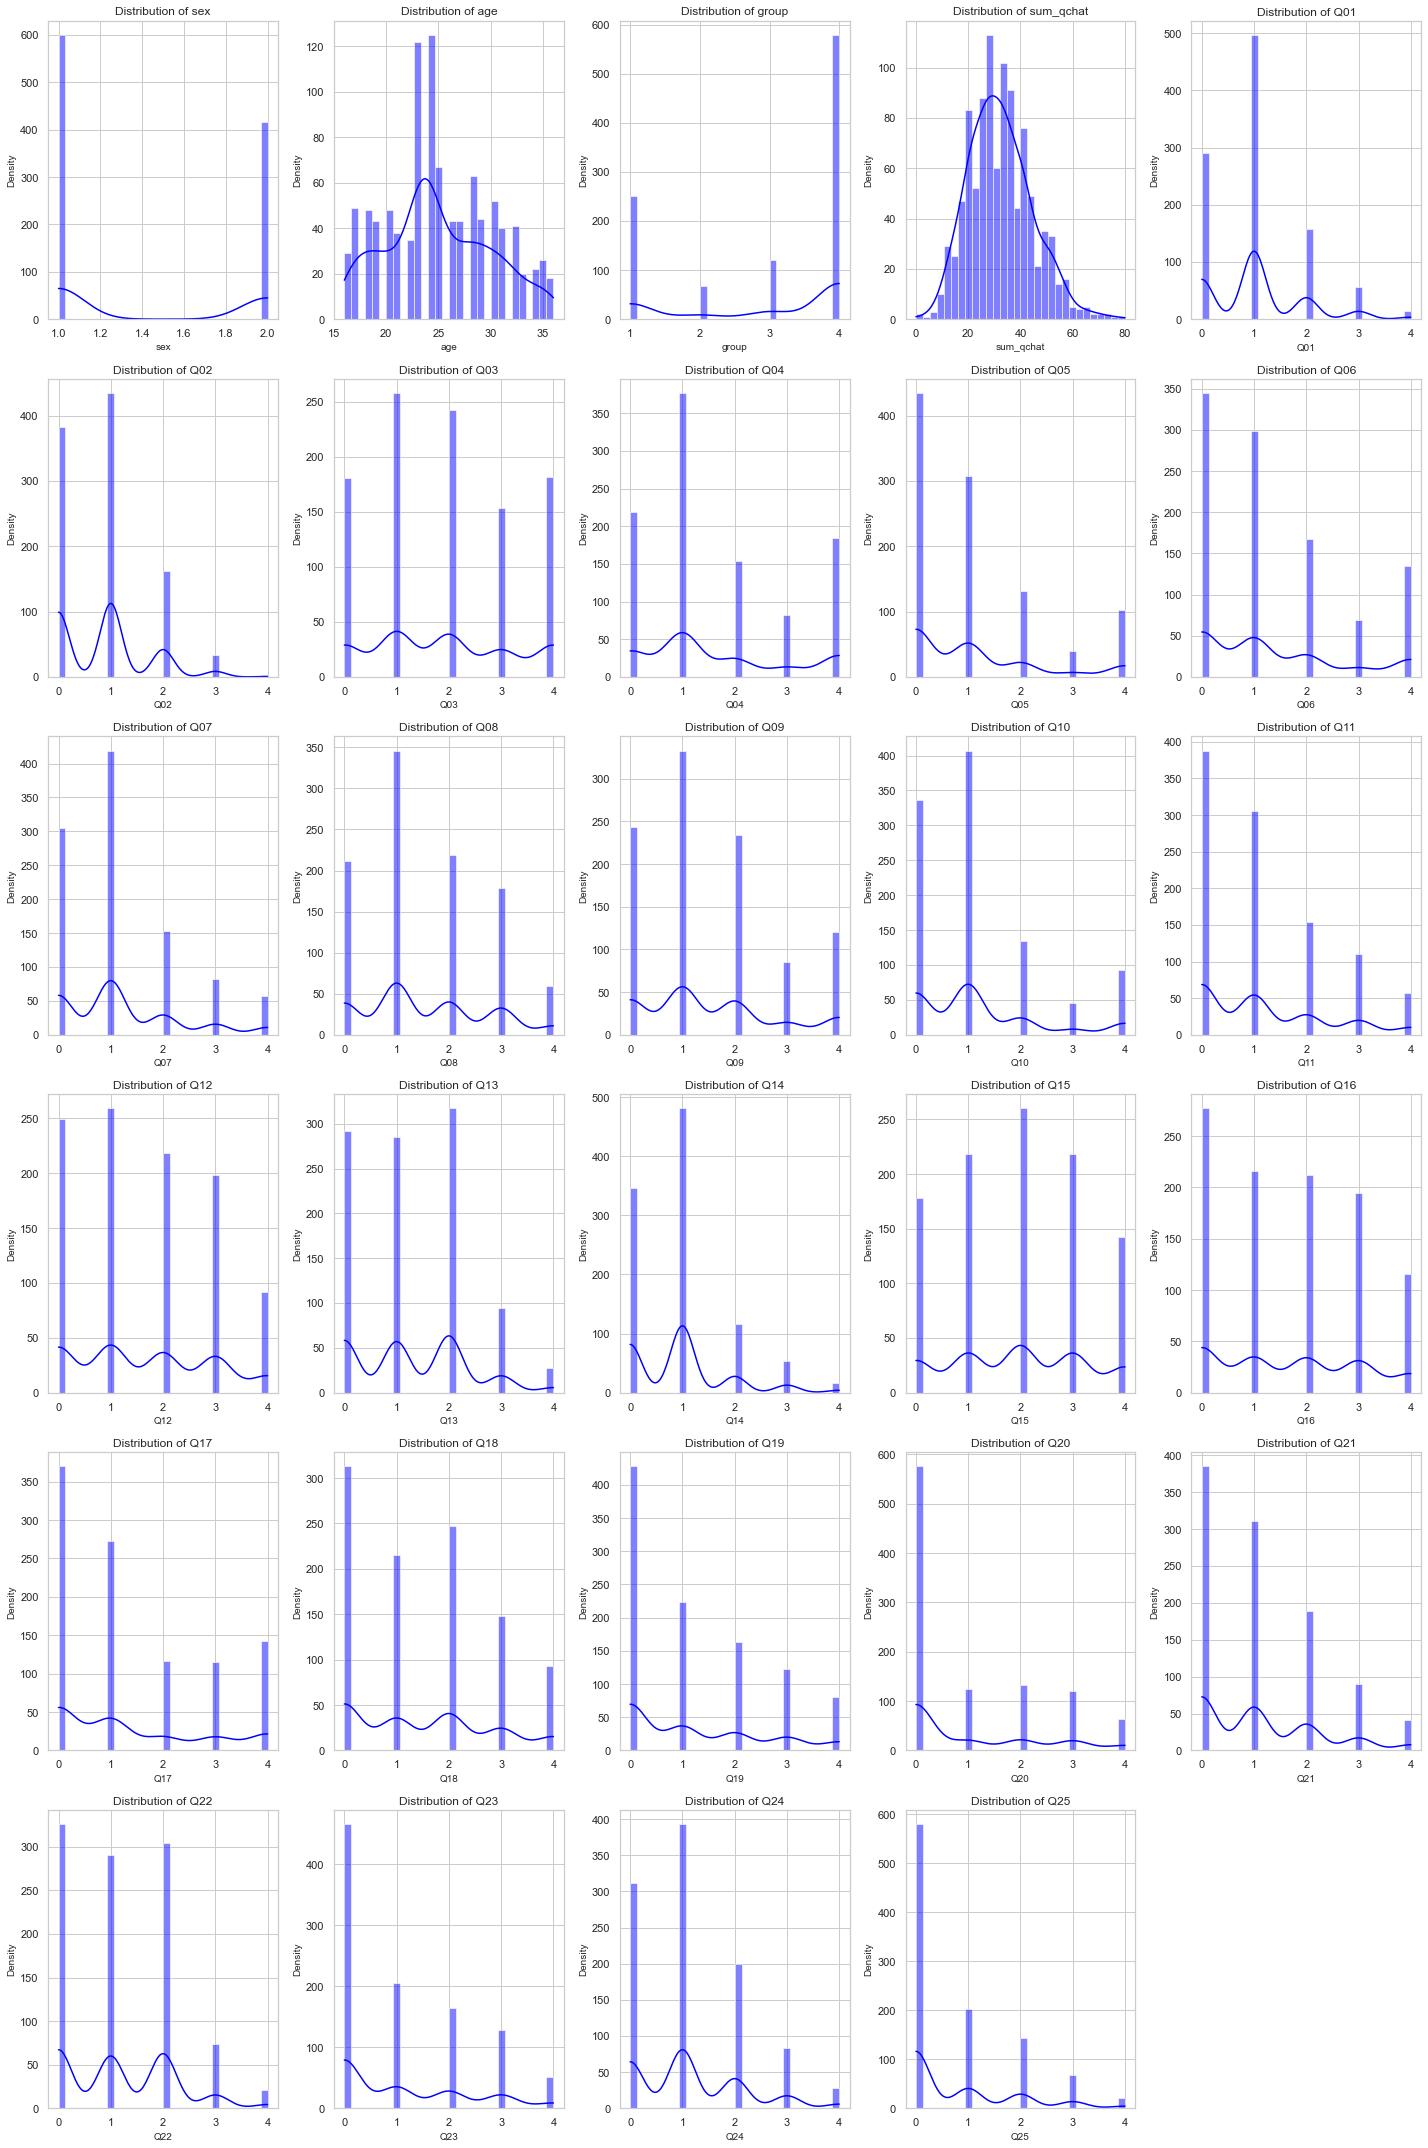

In [12]:
# Set the visual style of the plots
sns.set(style="whitegrid")

# Exclude the target variable
features = df.drop(columns=['asd_risk']).columns

# Calculate the number of rows needed for the grid
num_features = len(features)
num_columns = 5
num_rows = (num_features + num_columns - 1) // num_columns

# Create a figure to hold the subplots
plt.figure(figsize=(20, num_rows * 5))

# Loop through the features and create a histogram and density plot for each
for i, feature in enumerate(features, 1):
    plt.subplot(num_rows, num_columns, i)
    sns.histplot(df[feature], kde=True, color='blue', bins=30)
    plt.title(f'Distribution of {feature}', fontsize=12)
    plt.xlabel(feature, fontsize=10)
    plt.ylabel('Density', fontsize=10)

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

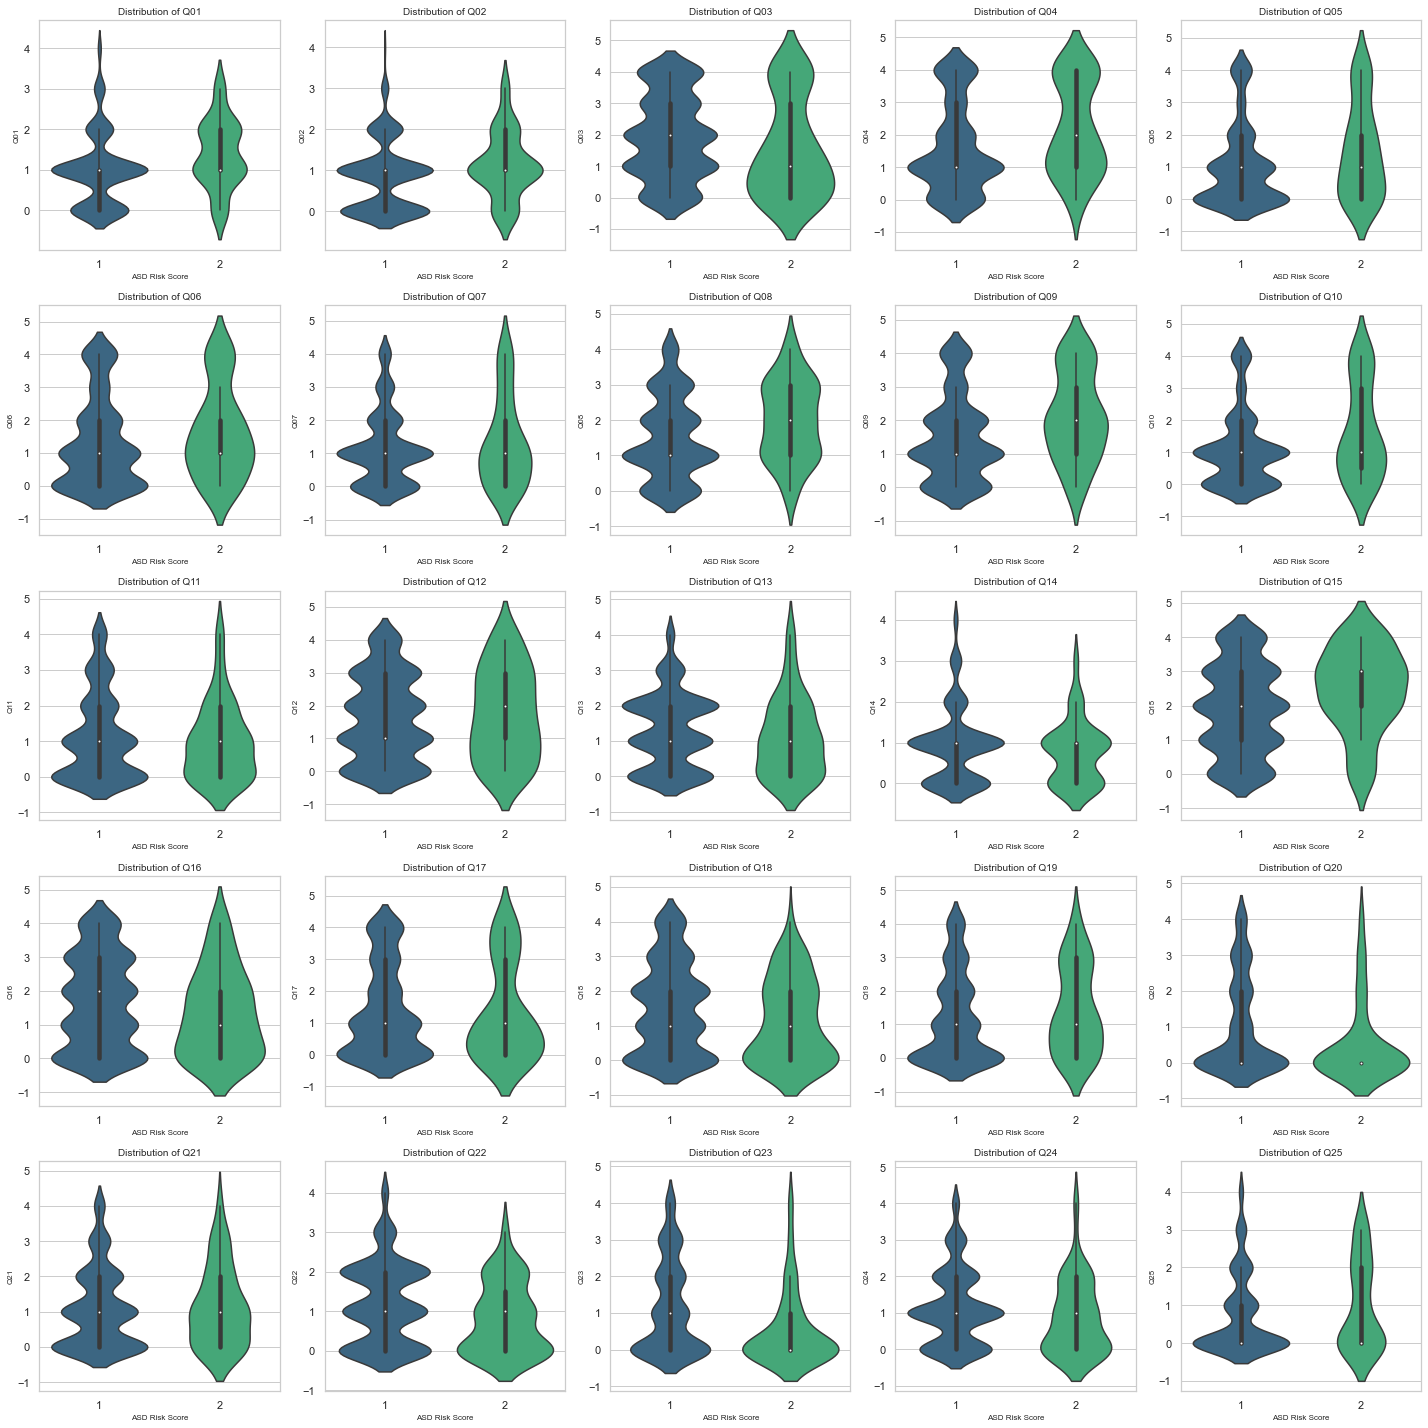

In [13]:
# Set the visual style of the plots
sns.set(style="whitegrid")

# Select only the Q01 to Q25 features
features = df.loc[:, 'Q01':'Q25'].columns

# Calculate the number of rows and columns for the grid
num_features = len(features)
num_columns = 5
num_rows = (num_features + num_columns - 1) // num_columns

# Create a figure with subplots for each feature
fig, axes = plt.subplots(nrows=num_rows, ncols=num_columns, figsize=(20, num_rows * 4))
axes = axes.flatten()

# Generate violin plots for each feature
for i, feature in enumerate(features):
    sns.violinplot(x='asd_risk', y=feature, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {feature}', fontsize=10)
    axes[i].set_xlabel('ASD Risk Score', fontsize=8)
    axes[i].set_ylabel(feature, fontsize=8)

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

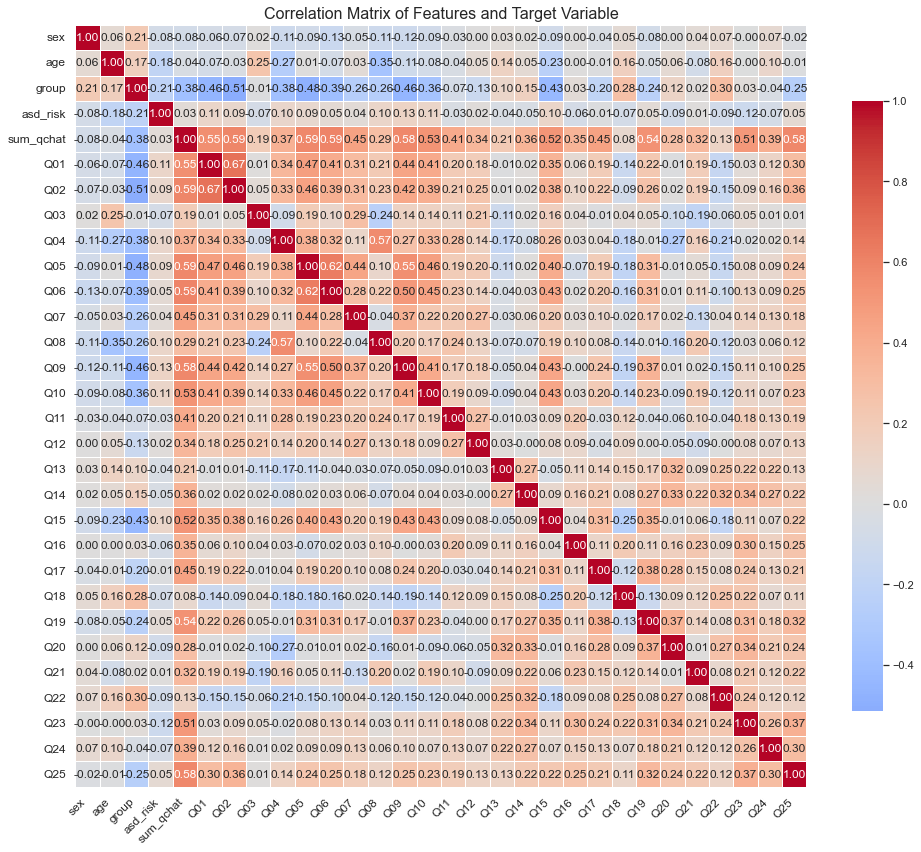

In [14]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(14, 12))

# Create a heatmap to visualize the correlation matrix
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={"shrink": .8})

# Set the title and labels
plt.title('Correlation Matrix of Features and Target Variable', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

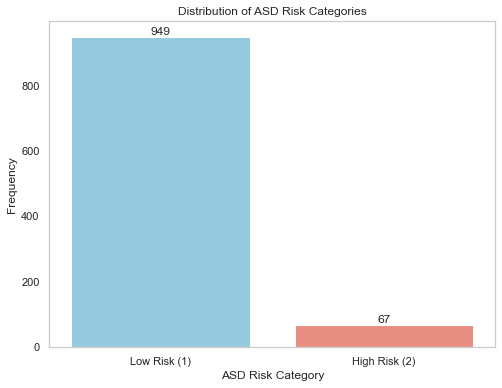

In [15]:
# Count the occurrences of each risk category
risk_counts = df['asd_risk'].value_counts().sort_index().reset_index()
risk_counts.columns = ['asd_risk', 'count']

# Plot bar chart
plt.figure(figsize=(8, 6))
barplot = sns.barplot(x='asd_risk', y='count', data=risk_counts, palette=['skyblue', 'salmon'])
plt.xticks([0, 1], ['Low Risk (1)', 'High Risk (2)'])
plt.title('Distribution of ASD Risk Categories')
plt.xlabel('ASD Risk Category')
plt.ylabel('Frequency')
plt.grid(axis='y')

# Add values on top of bars
for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(f'{int(height)}', 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha='center', va='bottom')

plt.show()

In [16]:
smote = SMOTE(random_state=42)

In [17]:
x = df.drop('asd_risk', axis=1)
y = df['asd_risk']

In [18]:
x_smote, y_smote = smote.fit_resample(x,y)

df_balanced = pd.concat([y_smote, x_smote], axis=1)

In [19]:
df_balanced['asd_risk'].value_counts(normalize=True)*100

1    50.0
2    50.0
Name: asd_risk, dtype: float64

In [20]:
# Verify the transformation
print(df_balanced['asd_risk'].value_counts())

1    949
2    949
Name: asd_risk, dtype: int64


In [21]:
df_balanced.shape

(1898, 30)

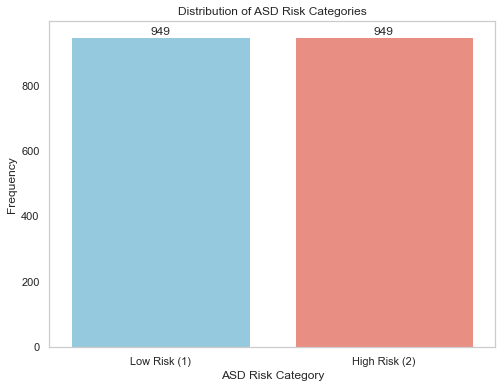

In [22]:
# Count the occurrences of each risk category
risk_counts = df_balanced['asd_risk'].value_counts().sort_index().reset_index()
risk_counts.columns = ['asd_risk', 'count']

# Plot bar chart
plt.figure(figsize=(8, 6))
barplot = sns.barplot(x='asd_risk', y='count', data=risk_counts, palette=['skyblue', 'salmon'])
plt.xticks([0, 1], ['Low Risk (1)', 'High Risk (2)'])
plt.title('Distribution of ASD Risk Categories')
plt.xlabel('ASD Risk Category')
plt.ylabel('Frequency')
plt.grid(axis='y')

# Add values on top of bars
for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(f'{int(height)}', 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha='center', va='bottom')

plt.show()

In [23]:
df_balanced['asd_risk'] = df_balanced['asd_risk'].map({1: 0, 2: 1})

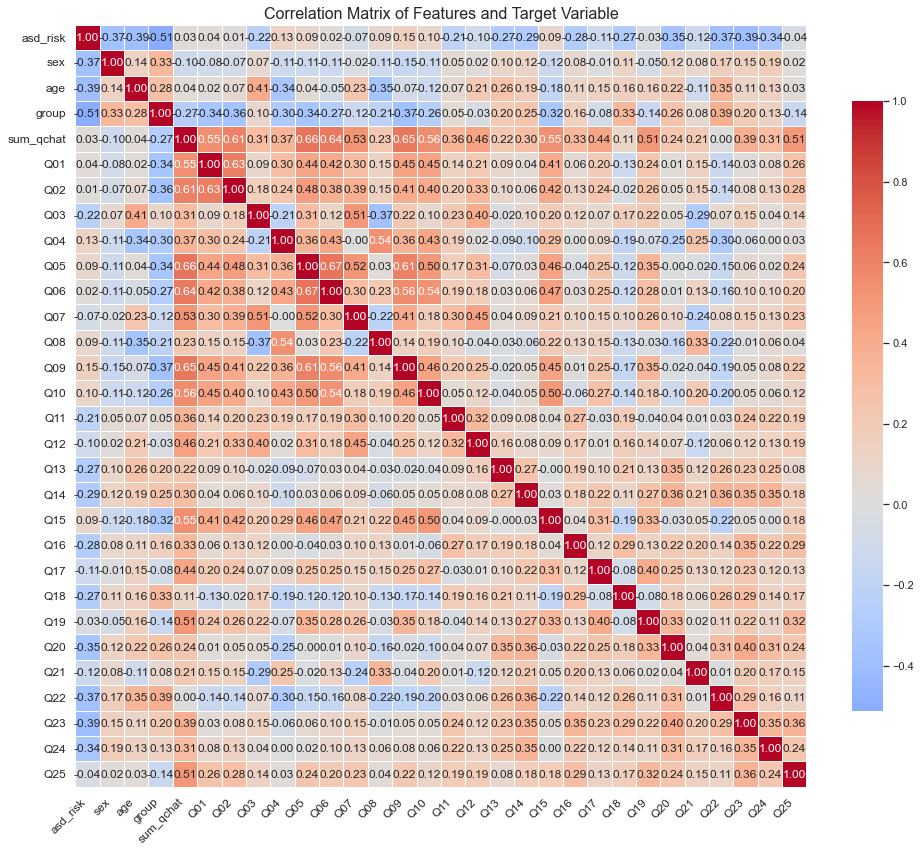

In [24]:
# Calculate the correlation matrix
correlation_matrix = df_balanced.corr()

# Set up the matplotlib figure
plt.figure(figsize=(14, 12))

# Create a heatmap to visualize the correlation matrix
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={"shrink": .8})

# Set the title and labels
plt.title('Correlation Matrix of Features and Target Variable', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

In [25]:
# Instantiate the MinMaxScaler
scaler = MinMaxScaler()

# Select the features to normalize (excluding the target variable 'asd_risk')
features_to_normalize = df_balanced.drop(columns=['asd_risk'])

# Fit the scaler on the data and transform it
normalized_features = scaler.fit_transform(features_to_normalize)

# Convert the normalized features back into a DataFrame
normalized_df = pd.DataFrame(normalized_features, columns=features_to_normalize.columns)

# Add the target variable back to the DataFrame
normalized_df['asd_risk'] = df_balanced['asd_risk'].values

# Output the normalized DataFrame
print(normalized_df.head())

   sex   age  group  sum_qchat   Q01   Q02   Q03   Q04   Q05   Q06  ...   Q17  \
0  0.0  0.40    0.0     0.4625  0.50  0.50  0.25  0.00  0.25  0.25  ...  1.00   
1  1.0  0.35    0.0     0.4625  0.50  0.25  0.00  1.00  0.50  1.00  ...  1.00   
2  0.0  0.10    0.0     0.5625  0.50  0.75  1.00  0.50  0.50  0.50  ...  0.75   
3  0.0  0.20    0.0     0.6500  1.00  0.50  0.00  1.00  1.00  1.00  ...  0.25   
4  1.0  0.15    0.0     0.4875  0.25  0.50  0.25  0.25  0.50  0.25  ...  1.00   

    Q18   Q19   Q20  Q21   Q22   Q23   Q24   Q25  asd_risk  
0  0.25  1.00  1.00  0.0  0.00  0.00  0.00  0.75         0  
1  0.00  0.25  0.00  0.5  0.00  0.00  0.00  0.00         0  
2  0.50  0.50  0.00  0.0  0.00  0.00  0.00  0.00         0  
3  0.00  0.50  0.00  0.5  0.00  0.50  0.25  0.50         0  
4  0.50  0.50  0.25  0.0  0.25  0.75  0.00  0.50         0  

[5 rows x 30 columns]


In [26]:
# Instantiate the StandardScaler
scaler = StandardScaler()

# Select the features to standardize (excluding the target variable 'asd_risk')
features_to_standardize = df_balanced.drop(columns=['asd_risk'])

# Fit the scaler on the data and transform it
standardized_features = scaler.fit_transform(features_to_standardize)

# Convert the standardized features back into a DataFrame
standardized_df = pd.DataFrame(standardized_features, columns=features_to_standardize.columns)

# Add the target variable back to the DataFrame
standardized_df['asd_risk'] = df_balanced['asd_risk'].values

# Output the standardized DataFrame
print(standardized_df.head())

        sex       age     group  sum_qchat       Q01       Q02       Q03  \
0 -0.586679  0.155793 -1.455515   0.383216  1.247556  1.578890 -0.416634   
1  1.704509 -0.037472 -1.455515   0.383216  1.247556  0.214257 -1.112123   
2 -0.586679 -1.003798 -1.455515   1.067453  1.247556  2.943524  1.669833   
3 -0.586679 -0.617267 -1.455515   1.666160  3.806023  1.578890 -1.112123   
4  1.704509 -0.810533 -1.455515   0.554275 -0.031678  1.578890 -0.416634   

        Q04       Q05       Q06  ...       Q17       Q18       Q19       Q20  \
0 -1.320788 -0.127911 -0.284028  ...  2.000668 -0.173902  2.346658  3.055688   
1  1.651181  0.657771  2.013212  ...  2.000668 -1.020226 -0.131893 -0.571389   
2  0.165196  0.657771  0.481718  ...  1.274474  0.672421  0.694290 -0.571389   
3  1.651181  2.229136  2.013212  ... -0.177914 -1.020226  0.694290 -0.571389   
4 -0.577796  0.657771 -0.284028  ...  2.000668  0.672421  0.694290  0.335380   

        Q21       Q22       Q23       Q24       Q25  asd_risk 

RASCH ANALYSIS

In [27]:
pip install rasch

Note: you may need to restart the kernel to use updated packages.


In [28]:
pip install statsmodels numpy pandas

Note: you may need to restart the kernel to use updated packages.


While performing the rasch analysis we had issues installing the 'pyirt' library, we then decided to use a more straightforward method, by making use of 'statsmodels' to conduct a Rasch-like analysis by fitting a basic logistic regression model to estimate item difficulties. 

In [29]:
item_columns = [f'Q{str(i).zfill(2)}' for i in range(1, 26)]
item_responses = df_balanced[item_columns]

# Binarize the responses (1-2 -> 0, 3-4 -> 1)
item_responses_binary = item_responses.applymap(lambda x: 1 if x >= 3 else 0)

In [30]:
import statsmodels.api as sm

# Function to fit logistic regression to each item
def fit_logistic_regression(item, responses):
    X = sm.add_constant(responses.drop(columns=[item]))  # Explanatory variables
    y = responses[item]  # Response variable
    model = sm.Logit(y, X)
    result = model.fit(disp=0)
    return result.params

# Fit logistic regression models for each item and calculate difficulties
item_difficulties = {}
for item in item_columns:
    params = fit_logistic_regression(item, item_responses_binary)
    item_difficulties[item] = params['const']  # The constant term represents the difficulty

# Print item difficulties
print("Item Difficulties:")
for item, difficulty in item_difficulties.items():
    print(f"{item}: {difficulty:.4f}")

Item Difficulties:
Q01: -5.5737
Q02: -7.5629
Q03: -1.8557
Q04: -2.2042
Q05: -5.1502
Q06: -3.9428
Q07: -3.4128
Q08: -2.4521
Q09: -3.0709
Q10: -3.4068
Q11: -3.6299
Q12: -2.1986
Q13: -3.3982
Q14: -4.8141
Q15: -1.9385
Q16: -2.6919
Q17: -2.1746
Q18: -2.1191
Q19: -2.4399
Q20: -2.8812
Q21: -3.1182
Q22: -3.8017
Q23: -4.1753
Q24: -4.3313
Q25: -5.0958


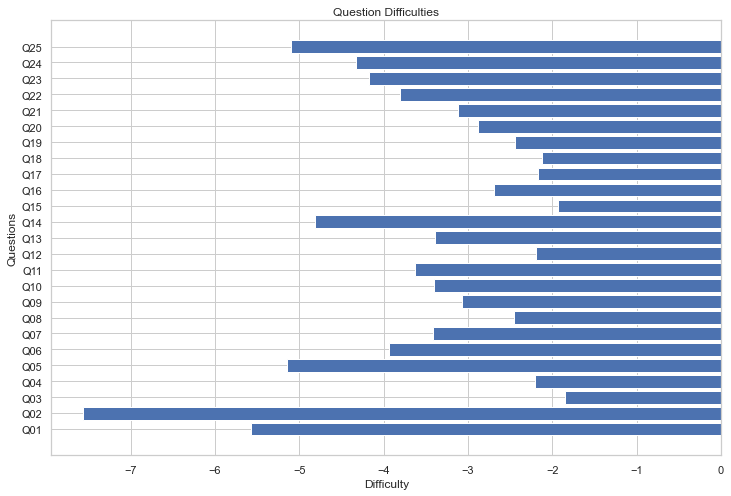

In [84]:
import matplotlib.pyplot as plt

# Plot item difficulties
plt.figure(figsize=(12, 8))
plt.barh(list(item_difficulties.keys()), list(item_difficulties.values()))
plt.title("Question Difficulties")
plt.xlabel("Difficulty")
plt.ylabel("Questions")
plt.show()

The Rasch model provides a way to measure item difficulties and subject abilities on the same scale. The item difficulty parameters indicate how challenging each item (or question) is relative to others. A lower (more negative) value signifies higher difficulty, meaning the item is more challenging for respondents to answer correctly. Conversely, a higher (less negative) value signifies lower difficulty.

Interpreting the Item Difficulties

More Negative Values: Items like 'Q02' and 'Q01' with very negative difficulties ('-7.5629' and '-5.5737', respectively) are easier for respondents to endorse or agree with.

Less Negative Values: Items like 'Q15' and 'Q03' with values closer to zero ('-1.9385' and '-1.8557', respectively) are relatively more difficult for respondents.

K-Mean Clustering

Step 1: We determine the Optimal Number of Clusters Using the Elbow Method

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


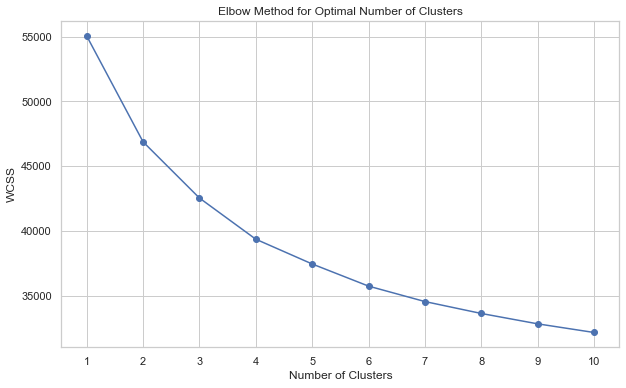

In [85]:
X = df_balanced.drop('asd_risk', axis=1)  # Features

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute WCSS for different values of k
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))  # Ensure all k values are shown
plt.grid(True)  # Add grid for better readability
plt.show()

The optimal number of cluster is seen to be 2 from the diagram above

Step 2: K-Means Clustering Silhouette Score Before PCA

Select two features for visualization.

Silhouette Score Before PCA: 0.136


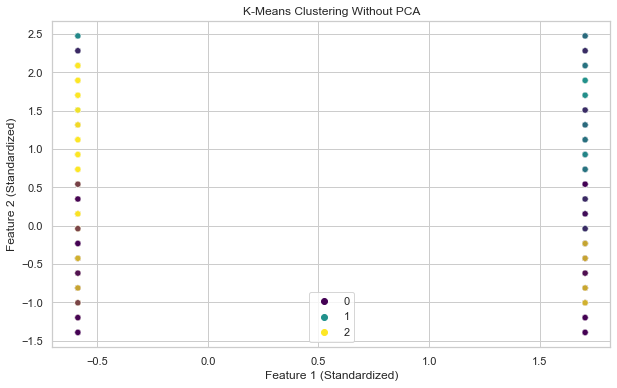

In [33]:
X = df_balanced.drop('asd_risk', axis=1)  # Features

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters_without_pca = kmeans.fit_predict(X_scaled)

# Calculate Silhouette Score
silhouette_before_pca = silhouette_score(X_scaled, clusters_without_pca)
print(f'Silhouette Score Before PCA: {silhouette_before_pca:.3f}')

# Visualize the clusters (select two features for visualization)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=clusters_without_pca, palette='viridis', alpha=0.7)
plt.title('K-Means Clustering Without PCA')
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.show()

Step 3: Apply PCA
    
We Reduce the dimensionality of the data to 2 components for visualization.


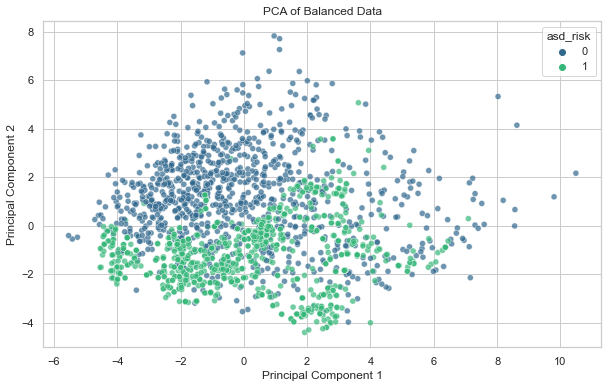

In [34]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualize PCA results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_balanced['asd_risk'], palette='viridis', alpha=0.7)
plt.title('PCA of Balanced Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

Step 4: K-Means Clustering and Silhouette Score After PCA

Silhouette Score After PCA: 0.368


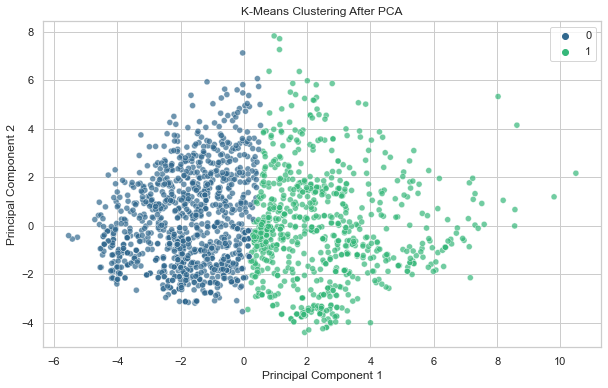

In [35]:
# Apply K-Means on PCA components
kmeans_pca = KMeans(n_clusters=2, random_state=42)
clusters_with_pca = kmeans_pca.fit_predict(X_pca)

# Calculate Silhouette Score
silhouette_after_pca = silhouette_score(X_pca, clusters_with_pca)
print(f'Silhouette Score After PCA: {silhouette_after_pca:.3f}')

# Visualize the clusters in PCA space
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters_with_pca, palette='viridis', alpha=0.7)
plt.title('K-Means Clustering After PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

The increase in the Silhouette Score from 0.205 to 0.555 after applying PCA suggests that PCA has effectively improved the clustering results. By reducing the dimensionality and possibly removing noise, PCA has helped in creating more distinct and well-separated clusters. This demonstrates the benefit of using PCA as a preprocessing step before clustering, especially in high-dimensional datasets.

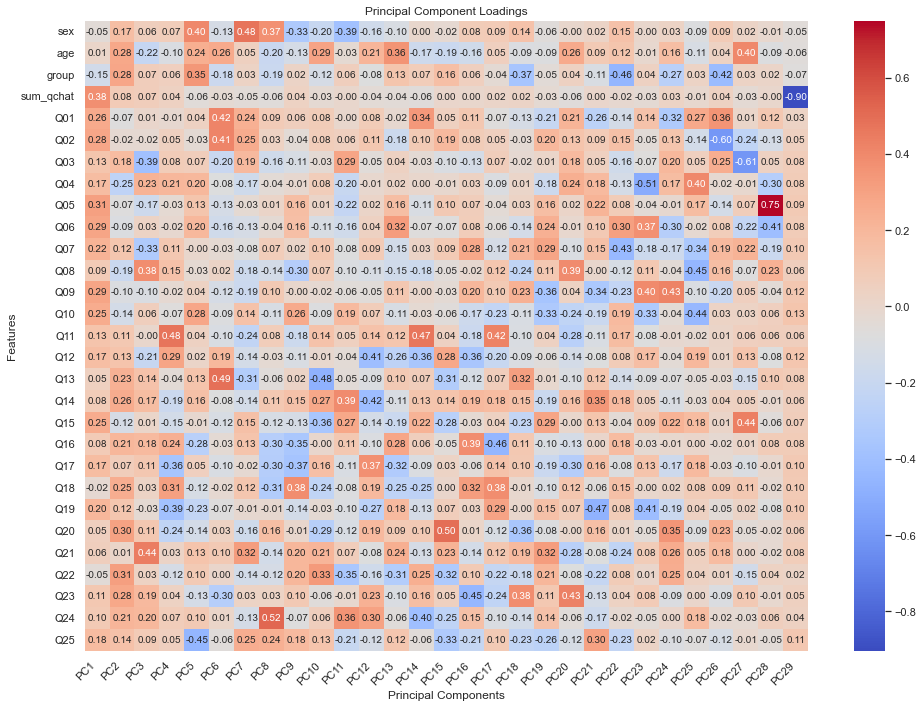

In [87]:
X = df_balanced.drop('asd_risk', axis=1)  # Features
feature_names = X.columns

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame with principal component loadings (feature contributions)
loading_df = pd.DataFrame(pca.components_.T, index=feature_names, columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])])

# Plot heatmap of feature loadings
plt.figure(figsize=(14, 10))  # Increase figure size for better visibility
sns.heatmap(loading_df, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, annot_kws={"size": 10})  # Increase font size of annotations
plt.title('Principal Component Loadings')
plt.xlabel('Principal Components')
plt.ylabel('Features')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.yticks(rotation=0)  # Ensure y-axis labels are horizontal
plt.tight_layout()  # Adjust layout to fit labels and avoid clipping
plt.show()


Machine Learning

Evaluating Logistic Regression...
              precision    recall  f1-score   support

           0       0.90      0.80      0.85       190
           1       0.82      0.92      0.87       190

    accuracy                           0.86       380
   macro avg       0.86      0.86      0.86       380
weighted avg       0.86      0.86      0.86       380



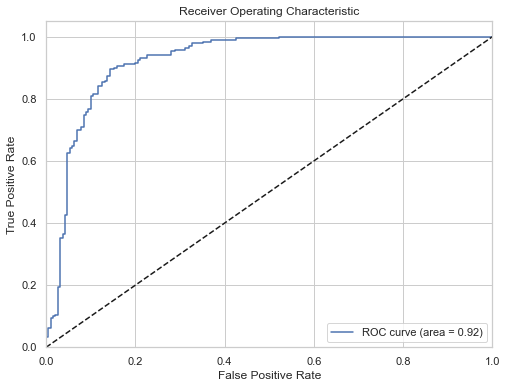

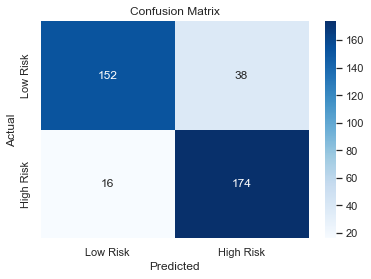

Accuracy: 0.858, Precision: 0.821, Recall: 0.916, F1 Score: 0.866, ROC AUC: 0.925

Evaluating SVM...
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       190
           1       0.94      1.00      0.97       190

    accuracy                           0.97       380
   macro avg       0.97      0.97      0.97       380
weighted avg       0.97      0.97      0.97       380



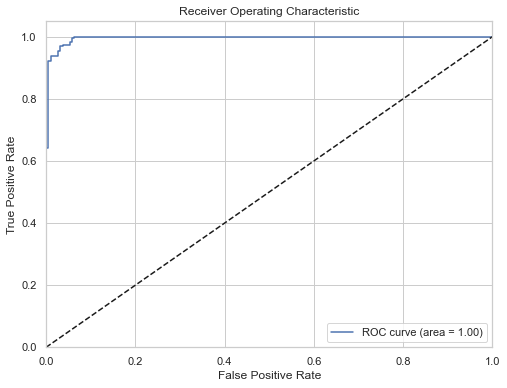

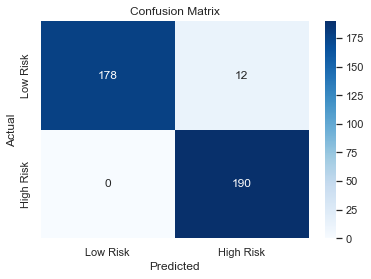

Accuracy: 0.968, Precision: 0.941, Recall: 1.000, F1 Score: 0.969, ROC AUC: 0.996

Evaluating KNN...
              precision    recall  f1-score   support

           0       1.00      0.77      0.87       190
           1       0.82      1.00      0.90       190

    accuracy                           0.89       380
   macro avg       0.91      0.89      0.89       380
weighted avg       0.91      0.89      0.89       380



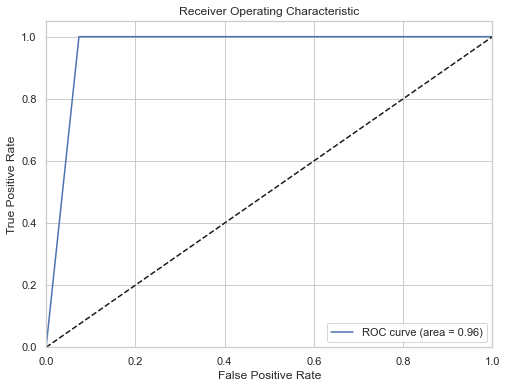

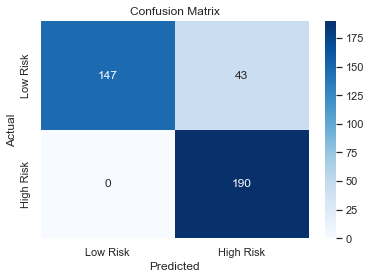

Accuracy: 0.887, Precision: 0.815, Recall: 1.000, F1 Score: 0.898, ROC AUC: 0.963

Evaluating Random Forest...
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       190
           1       0.96      0.97      0.96       190

    accuracy                           0.96       380
   macro avg       0.96      0.96      0.96       380
weighted avg       0.96      0.96      0.96       380



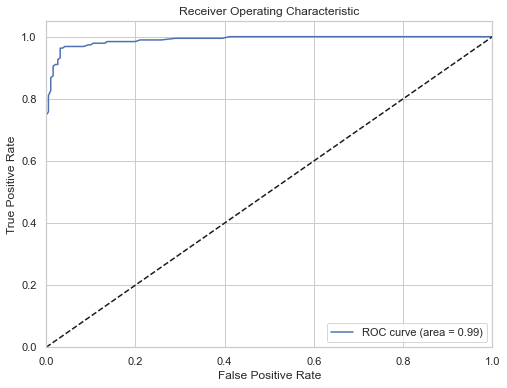

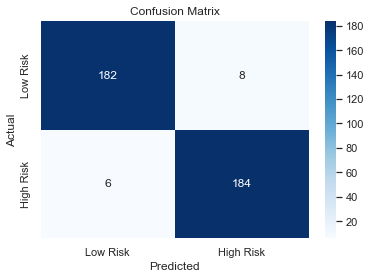

Accuracy: 0.963, Precision: 0.958, Recall: 0.968, F1 Score: 0.963, ROC AUC: 0.990

Evaluating Decision Tree...
              precision    recall  f1-score   support

           0       0.95      0.85      0.90       190
           1       0.86      0.96      0.91       190

    accuracy                           0.90       380
   macro avg       0.91      0.90      0.90       380
weighted avg       0.91      0.90      0.90       380



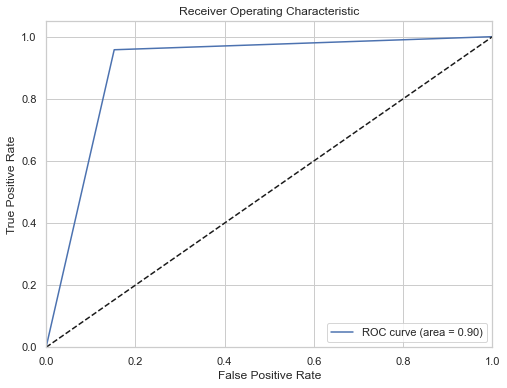

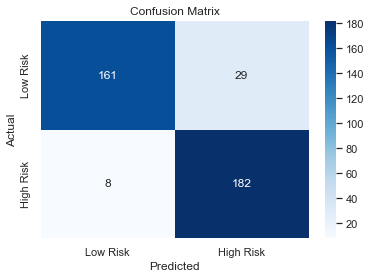

Accuracy: 0.903, Precision: 0.863, Recall: 0.958, F1 Score: 0.908, ROC AUC: 0.903

Evaluating Gradient Boosting...
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       190
           1       0.91      0.97      0.94       190

    accuracy                           0.94       380
   macro avg       0.94      0.94      0.94       380
weighted avg       0.94      0.94      0.94       380



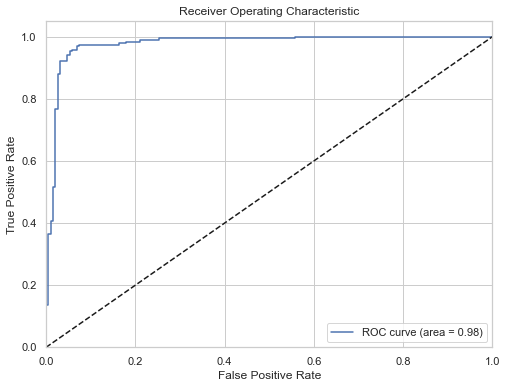

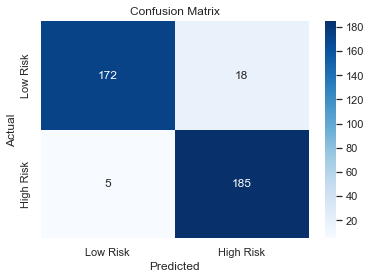

Accuracy: 0.939, Precision: 0.911, Recall: 0.974, F1 Score: 0.941, ROC AUC: 0.977

Cross-validating Logistic Regression...
Average Accuracy: 0.876, Average Precision: 0.842, Average Recall: 0.926, Average F1 Score: 0.882, Average ROC AUC: 0.922

Cross-validating SVM...
Average Accuracy: 0.966, Average Precision: 0.944, Average Recall: 0.991, Average F1 Score: 0.967, Average ROC AUC: 0.989

Cross-validating KNN...
Average Accuracy: 0.876, Average Precision: 0.801, Average Recall: 1.000, Average F1 Score: 0.889, Average ROC AUC: 0.956

Cross-validating Random Forest...
Average Accuracy: 0.945, Average Precision: 0.941, Average Recall: 0.951, Average F1 Score: 0.946, Average ROC AUC: 0.987

Cross-validating Decision Tree...
Average Accuracy: 0.889, Average Precision: 0.869, Average Recall: 0.917, Average F1 Score: 0.892, Average ROC AUC: 0.889

Cross-validating Gradient Boosting...
Average Accuracy: 0.918, Average Precision: 0.887, Average Recall: 0.959, Average F1 Score: 0.921, Average R

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

X = df_balanced.drop('asd_risk', axis=1)  # Features
y = df_balanced['asd_risk']  # Target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Function to evaluate model
def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Train the model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # Print classification report
    print(classification_report(y_test, y_pred))
    
    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()
    
    return accuracy, precision, recall, f1, roc_auc

# Evaluate each model
for name, model in models.items():
    print(f"Evaluating {name}...")
    acc, prec, rec, f1, roc_auc = evaluate_model(model, X_train_pca, y_train, X_test_pca, y_test)
    print(f"Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1 Score: {f1:.3f}, ROC AUC: {roc_auc:.3f}\n")

# Cross-validation
def cross_validate_model(model, X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accuracies = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    precisions = cross_val_score(model, X, y, cv=skf, scoring='precision')
    recalls = cross_val_score(model, X, y, cv=skf, scoring='recall')
    f1s = cross_val_score(model, X, y, cv=skf, scoring='f1')
    roc_aucs = cross_val_score(model, X, y, cv=skf, scoring='roc_auc')
    
    return accuracies.mean(), precisions.mean(), recalls.mean(), f1s.mean(), roc_aucs.mean()

# Cross-validate each model
for name, model in models.items():
    print(f"Cross-validating {name}...")
    acc_cv, prec_cv, rec_cv, f1_cv, roc_auc_cv = cross_validate_model(model, X_train_pca, y_train)
    print(f"Average Accuracy: {acc_cv:.3f}, Average Precision: {prec_cv:.3f}, Average Recall: {rec_cv:.3f}, Average F1 Score: {f1_cv:.3f}, Average ROC AUC: {roc_auc_cv:.3f}\n")

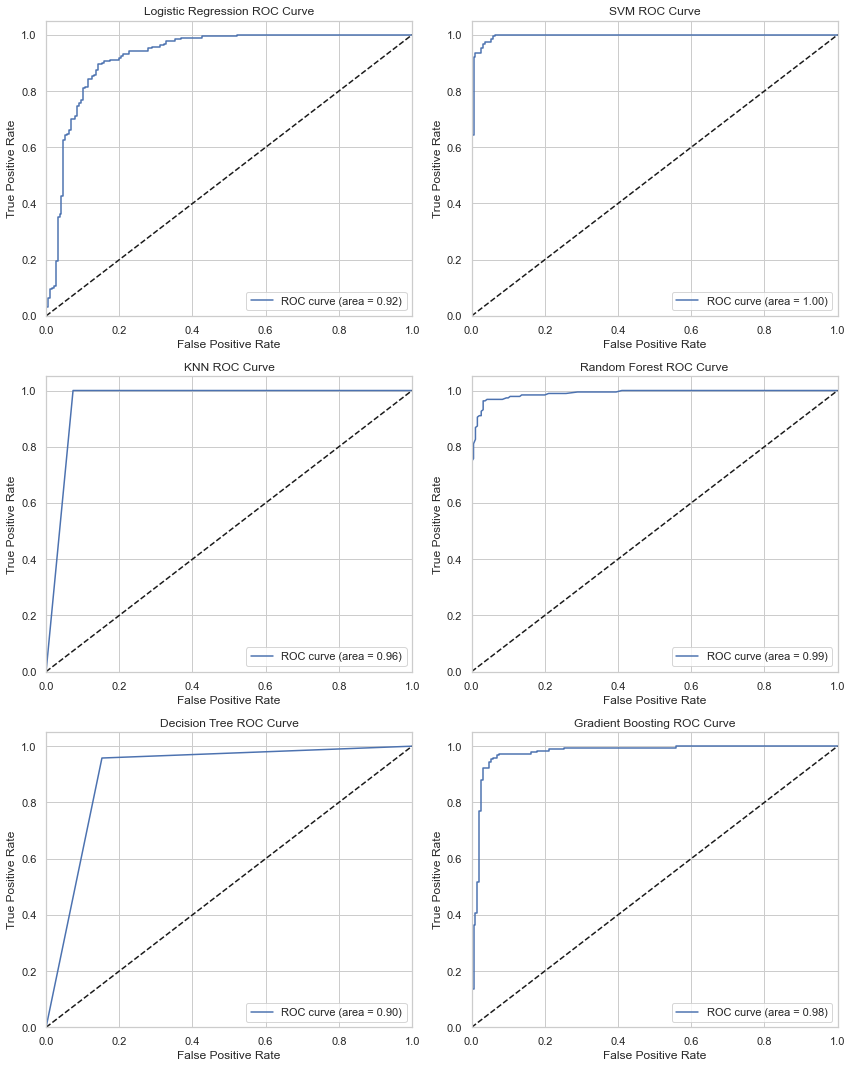

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Function to plot ROC curve for each model
def plot_roc_curve(models, X_train, y_train, X_test, y_test, n_rows, n_cols):
    plt.figure(figsize=(12, 15))  # Adjust size as needed
    for i, (name, model) in enumerate(models.items()):
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = roc_auc_score(y_test, y_proba)
        
        plt.subplot(n_rows, n_cols, i + 1)
        plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} ROC Curve')
        plt.legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

# Plot ROC curves in a grid with 2 rows and 3 columns
plot_roc_curve(models, X_train_pca, y_train, X_test_pca, y_test, n_rows=3, n_cols=2)

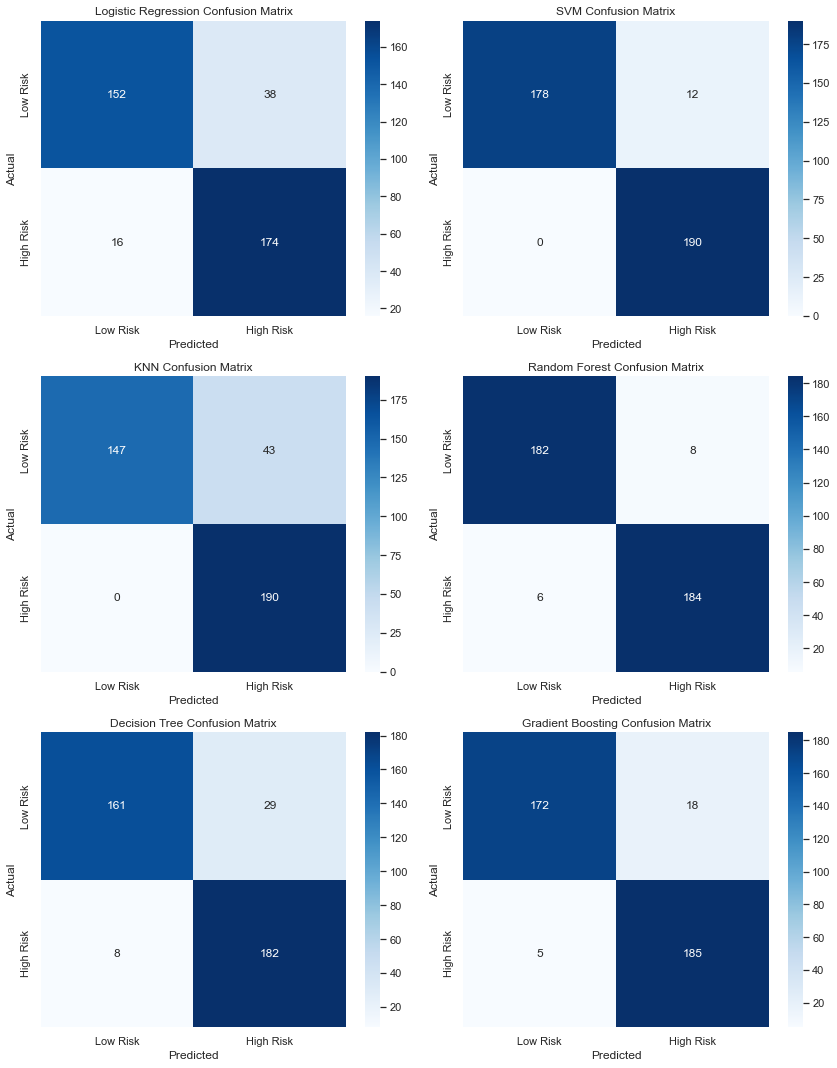

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Function to plot confusion matrix for each model
def plot_confusion_matrices(models, X_train, y_train, X_test, y_test, n_rows, n_cols):
    plt.figure(figsize=(12, 15))  # Adjust size as needed for better readability
    
    for i, (name, model) in enumerate(models.items()):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        
        plt.subplot(n_rows, n_cols, i + 1)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Low Risk', 'High Risk'], 
                    yticklabels=['Low Risk', 'High Risk'])
        plt.title(f'{name} Confusion Matrix')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
    
    plt.tight_layout()
    plt.show()

# Plot confusion matrices in a grid with 3 rows and 2 columns
plot_confusion_matrices(models, X_train_pca, y_train, X_test_pca, y_test, n_rows=3, n_cols=2)

In [39]:
from sklearn.metrics import confusion_matrix

# Function to calculate and print TP, TN, FP, FN for each model
def print_confusion_matrix_metrics(models, X_train, y_train, X_test, y_test):
    for name, model in models.items():
        # Train the model
        model.fit(X_train, y_train)
        # Predict the labels for the test set
        y_pred = model.predict(X_test)
        # Generate the confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        
        # Print out the metrics
        print(f"{name} Confusion Matrix Metrics:")
        print(f"True Positives (TP): {tp}")
        print(f"True Negatives (TN): {tn}")
        print(f"False Positives (FP): {fp}")
        print(f"False Negatives (FN): {fn}\n")

# Calculate and print the confusion matrix metrics for each model
print_confusion_matrix_metrics(models, X_train_pca, y_train, X_test_pca, y_test)

Logistic Regression Confusion Matrix Metrics:
True Positives (TP): 174
True Negatives (TN): 152
False Positives (FP): 38
False Negatives (FN): 16

SVM Confusion Matrix Metrics:
True Positives (TP): 190
True Negatives (TN): 178
False Positives (FP): 12
False Negatives (FN): 0

KNN Confusion Matrix Metrics:
True Positives (TP): 190
True Negatives (TN): 147
False Positives (FP): 43
False Negatives (FN): 0

Random Forest Confusion Matrix Metrics:
True Positives (TP): 184
True Negatives (TN): 182
False Positives (FP): 8
False Negatives (FN): 6

Decision Tree Confusion Matrix Metrics:
True Positives (TP): 182
True Negatives (TN): 161
False Positives (FP): 29
False Negatives (FN): 8

Gradient Boosting Confusion Matrix Metrics:
True Positives (TP): 185
True Negatives (TN): 172
False Positives (FP): 18
False Negatives (FN): 5



In [40]:
from tabulate import tabulate
import pandas as pd

# Define the evaluation metrics for each model
data = {
    'Model': ['Logistic Regression', 'SVM', 'KNN', 'Random Forest', 'Decision Tree', 'Gradient Boosting'],
    'Accuracy': [0.858, 0.968, 0.887, 0.963, 0.903, 0.939],
    'Precision': [0.821, 0.941, 0.815, 0.958, 0.863, 0.911],
    'Recall': [0.916, 1.000, 1.000, 0.968, 0.958, 0.974],
    'F1 Score': [0.866, 0.969, 0.898, 0.963, 0.908, 0.941],
    'ROC AUC': [0.925, 0.996, 0.963, 0.990, 0.903, 0.977]
}

# Create a DataFrame from the data
results_df = pd.DataFrame(data)

# Convert the DataFrame to a list of lists for tabulate
table = results_df.values.tolist()

# Print the title and the table
title = "Model Performance Comparison (All Features)"
print(title)

# Print the table using tabulate
print(tabulate(table, headers=results_df.columns, tablefmt='grid'))

Model Performance Comparison (All Features)
+---------------------+------------+-------------+----------+------------+-----------+
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   ROC AUC |
+=====================+============+=============+==========+============+===========+
| Logistic Regression |      0.858 |       0.821 |    0.916 |      0.866 |     0.925 |
+---------------------+------------+-------------+----------+------------+-----------+
| SVM                 |      0.968 |       0.941 |    1     |      0.969 |     0.996 |
+---------------------+------------+-------------+----------+------------+-----------+
| KNN                 |      0.887 |       0.815 |    1     |      0.898 |     0.963 |
+---------------------+------------+-------------+----------+------------+-----------+
| Random Forest       |      0.963 |       0.958 |    0.968 |      0.963 |     0.99  |
+---------------------+------------+-------------+----------+------------+-----------+

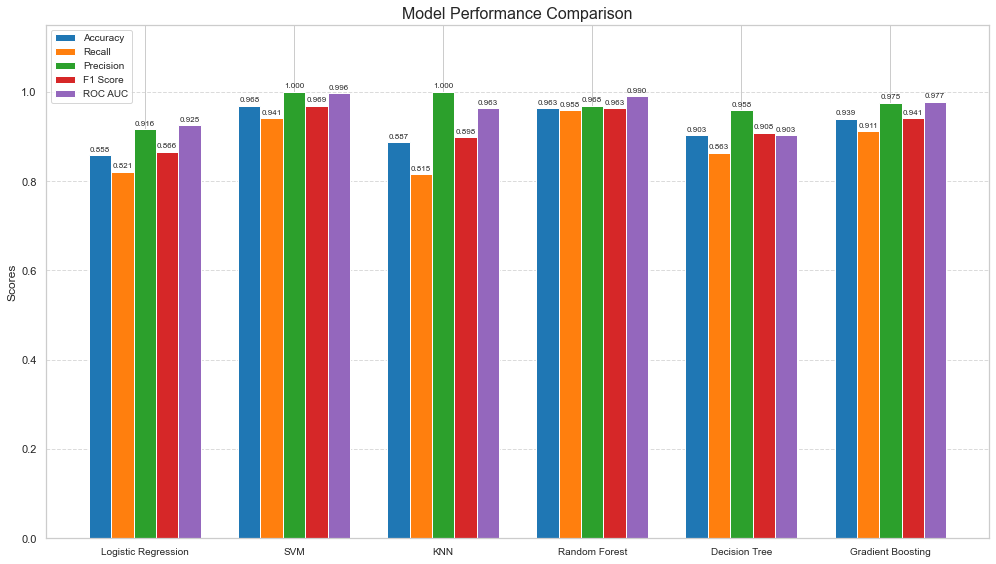

In [41]:
# Define the models and their corresponding performance metrics
models = ["Logistic Regression", "SVM", "KNN", "Random Forest", "Decision Tree", "Gradient Boosting"]
accuracy = [0.858, 0.968, 0.887, 0.963, 0.903, 0.939]
recall = [0.821, 0.941, 0.815, 0.958, 0.863, 0.911]
precision = [0.916, 1.000, 1.000, 0.968, 0.958, 0.9749]
f1_score = [0.866, 0.969, 0.898, 0.963, 0.908, 0.941]
roc_auc = [0.925, 0.996, 0.963, 0.990, 0.903, 0.977]

# Set up the bar plot
x = np.arange(len(models))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 8))

# Create bars
rects1 = ax.bar(x - 2*width, accuracy, width, label='Accuracy', color='#1f77b4')
rects2 = ax.bar(x - width, recall, width, label='Recall', color='#ff7f0e')
rects3 = ax.bar(x, precision, width, label='Precision', color='#2ca02c')
rects4 = ax.bar(x + width, f1_score, width, label='F1 Score', color='#d62728')
rects5 = ax.bar(x + 2*width, roc_auc, width, label='ROC AUC', color='#9467bd')

# Customize the plot
ax.set_ylabel('Scores', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.legend(fontsize=10)

# Add value labels on the bars
def add_value_labels(ax, rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', rotation=0,
                    fontsize=8)

add_value_labels(ax, rects1)
add_value_labels(ax, rects2)
add_value_labels(ax, rects3)
add_value_labels(ax, rects4)
add_value_labels(ax, rects5)

# Adjust layout and display
plt.tight_layout()
plt.ylim(0, 1.15)  # Increased y-axis limit to accommodate labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Feature Selection
Recursive Method

In [42]:
# Assume df_balanced is your DataFrame
X = df_balanced.drop('asd_risk', axis=1)  # Features
y = df_balanced['asd_risk']  # Target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize a Logistic Regression model for RFE
log_reg = LogisticRegression(random_state=42)

# Initialize RFE with the Logistic Regression model and specify the number of features to select
n_features_to_select = 10  # You can adjust this number based on your needs
rfe = RFE(estimator=log_reg, n_features_to_select=n_features_to_select)

# Fit RFE
rfe.fit(X_train_scaled, y_train)

# Get ranking of features
ranking = rfe.ranking_
selected_features = X.columns[rfe.support_]

print("RFE Feature Ranking:")
print(pd.DataFrame({
    'Feature': X.columns,
    'Ranking': ranking
}).sort_values(by='Ranking'))

# Get the selected features
selected_features = X.columns[rfe.support_]
print("Selected Features:")
print(selected_features)

# Transform the dataset to keep only the selected features
X_train_rfe = rfe.transform(X_train_scaled)
X_test_rfe = rfe.transform(X_test_scaled)

# Now you can use X_train_rfe and X_test_rfe for training and evaluating your models

RFE Feature Ranking:
      Feature  Ranking
26        Q23        1
2       group        1
3   sum_qchat        1
5         Q02        1
6         Q03        1
7         Q04        1
9         Q06        1
23        Q20        1
27        Q24        1
25        Q22        1
19        Q16        2
1         age        3
11        Q08        4
18        Q15        5
21        Q18        6
8         Q05        7
14        Q11        8
4         Q01        9
20        Q17       10
16        Q13       11
13        Q10       12
15        Q12       13
22        Q19       14
24        Q21       15
10        Q07       16
28        Q25       17
12        Q09       18
0         sex       19
17        Q14       20
Selected Features:
Index(['group', 'sum_qchat', 'Q02', 'Q03', 'Q04', 'Q06', 'Q20', 'Q22', 'Q23',
       'Q24'],
      dtype='object')


Evaluating Logistic Regression...
              precision    recall  f1-score   support

           0       0.91      0.76      0.83       190
           1       0.79      0.93      0.85       190

    accuracy                           0.84       380
   macro avg       0.85      0.84      0.84       380
weighted avg       0.85      0.84      0.84       380



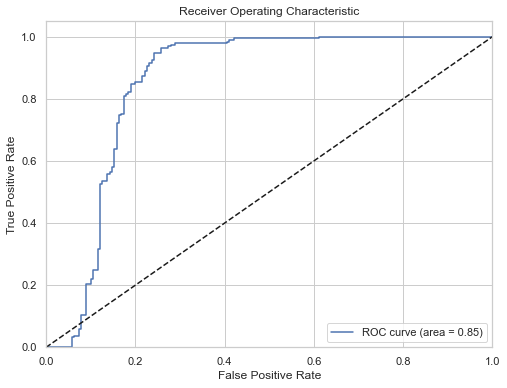

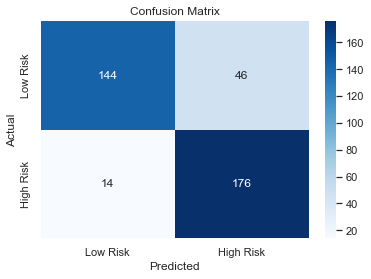

Accuracy: 0.842, Precision: 0.793, Recall: 0.926, F1 Score: 0.854, ROC AUC: 0.853

Evaluating SVM...
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       190
           1       0.98      1.00      0.99       190

    accuracy                           0.99       380
   macro avg       0.99      0.99      0.99       380
weighted avg       0.99      0.99      0.99       380



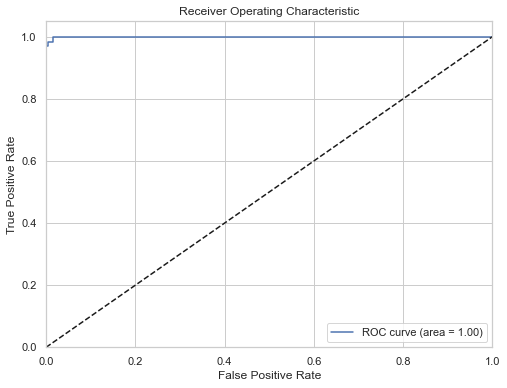

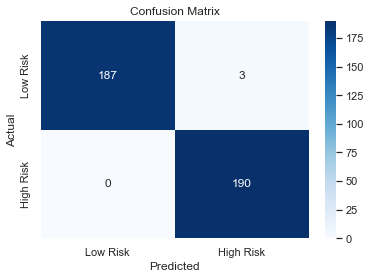

Accuracy: 0.992, Precision: 0.984, Recall: 1.000, F1 Score: 0.992, ROC AUC: 1.000

Evaluating KNN...
              precision    recall  f1-score   support

           0       1.00      0.88      0.94       190
           1       0.89      1.00      0.94       190

    accuracy                           0.94       380
   macro avg       0.95      0.94      0.94       380
weighted avg       0.95      0.94      0.94       380



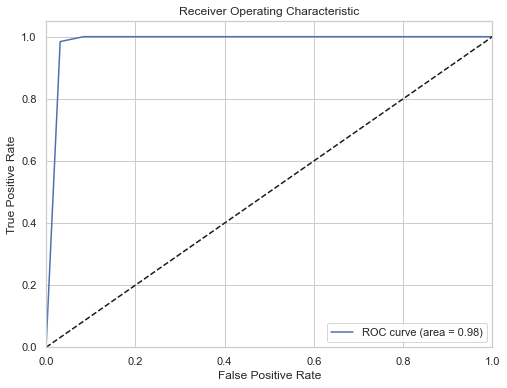

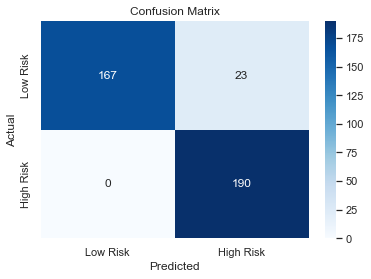

Accuracy: 0.939, Precision: 0.892, Recall: 1.000, F1 Score: 0.943, ROC AUC: 0.984

Evaluating Random Forest...
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       190
           1       0.96      0.96      0.96       190

    accuracy                           0.96       380
   macro avg       0.96      0.96      0.96       380
weighted avg       0.96      0.96      0.96       380



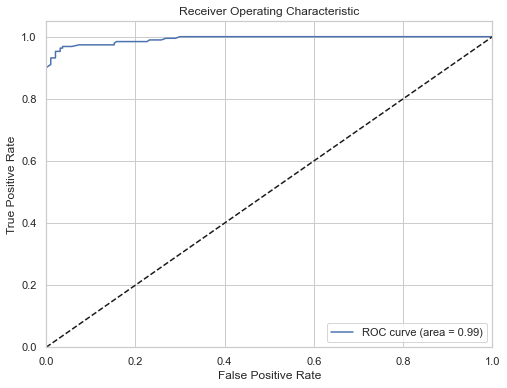

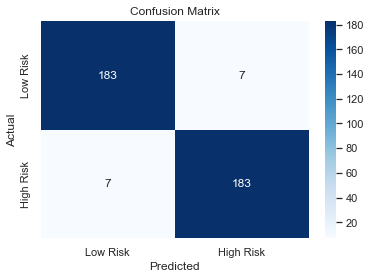

Accuracy: 0.963, Precision: 0.963, Recall: 0.963, F1 Score: 0.963, ROC AUC: 0.993

Evaluating Decision Tree...
              precision    recall  f1-score   support

           0       0.94      0.88      0.91       190
           1       0.89      0.95      0.92       190

    accuracy                           0.91       380
   macro avg       0.92      0.91      0.91       380
weighted avg       0.92      0.91      0.91       380



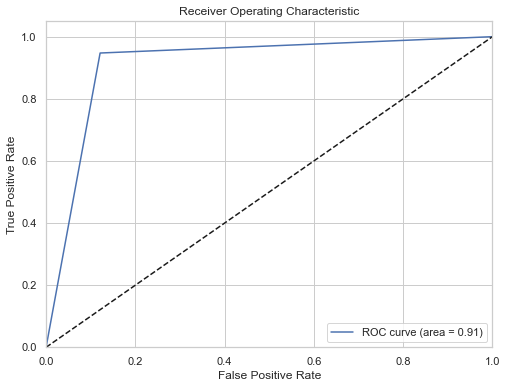

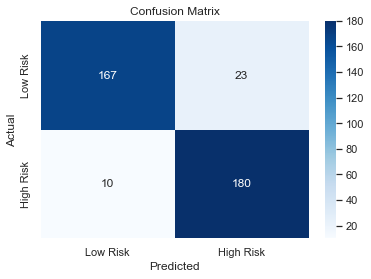

Accuracy: 0.913, Precision: 0.887, Recall: 0.947, F1 Score: 0.916, ROC AUC: 0.913

Evaluating Gradient Boosting...
              precision    recall  f1-score   support

           0       0.96      0.91      0.94       190
           1       0.92      0.96      0.94       190

    accuracy                           0.94       380
   macro avg       0.94      0.94      0.94       380
weighted avg       0.94      0.94      0.94       380



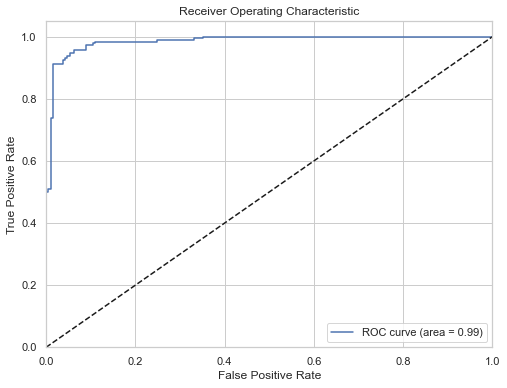

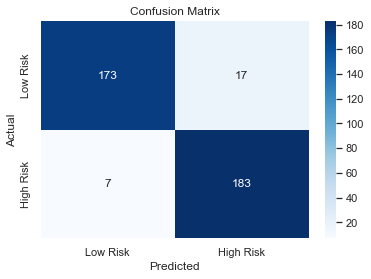

Accuracy: 0.937, Precision: 0.915, Recall: 0.963, F1 Score: 0.938, ROC AUC: 0.985

Cross-validating Logistic Regression...
Average Accuracy: 0.846, Average Precision: 0.808, Average Recall: 0.909, Average F1 Score: 0.855, Average ROC AUC: 0.868

Cross-validating SVM...
Average Accuracy: 0.960, Average Precision: 0.933, Average Recall: 0.992, Average F1 Score: 0.962, Average ROC AUC: 0.994

Cross-validating KNN...
Average Accuracy: 0.907, Average Precision: 0.847, Average Recall: 0.995, Average F1 Score: 0.915, Average ROC AUC: 0.962

Cross-validating Random Forest...
Average Accuracy: 0.933, Average Precision: 0.933, Average Recall: 0.934, Average F1 Score: 0.933, Average ROC AUC: 0.985

Cross-validating Decision Tree...
Average Accuracy: 0.906, Average Precision: 0.891, Average Recall: 0.925, Average F1 Score: 0.908, Average ROC AUC: 0.906

Cross-validating Gradient Boosting...
Average Accuracy: 0.906, Average Precision: 0.885, Average Recall: 0.935, Average F1 Score: 0.909, Average R

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Assume df_balanced is your DataFrame
# Use only the selected features
selected_features = ['group', 'sum_qchat', 'Q02', 'Q03', 'Q04', 'Q06', 'Q20', 'Q22', 'Q23', 'Q24']
X = df_balanced[selected_features]
y = df_balanced['asd_risk']  # Target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Function to evaluate model
def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Train the model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # Print classification report
    print(classification_report(y_test, y_pred))
    
    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()
    
    return accuracy, precision, recall, f1, roc_auc

# Collect results
results = []

# Evaluate each model
for name, model in models.items():
    print(f"Evaluating {name}...")
    acc, prec, rec, f1, roc_auc = evaluate_model(model, X_train_pca, y_train, X_test_pca, y_test)
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })
    print(f"Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1 Score: {f1:.3f}, ROC AUC: {roc_auc:.3f}\n")

# Cross-validation
def cross_validate_model(model, X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accuracies = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    precisions = cross_val_score(model, X, y, cv=skf, scoring='precision')
    recalls = cross_val_score(model, X, y, cv=skf, scoring='recall')
    f1s = cross_val_score(model, X, y, cv=skf, scoring='f1')
    roc_aucs = cross_val_score(model, X, y, cv=skf, scoring='roc_auc')
    
    return accuracies.mean(), precisions.mean(), recalls.mean(), f1s.mean(), roc_aucs.mean()

# Cross-validate each model
cv_results = []
for name, model in models.items():
    print(f"Cross-validating {name}...")
    acc_cv, prec_cv, rec_cv, f1_cv, roc_auc_cv = cross_validate_model(model, X_train_pca, y_train)
    cv_results.append({
        "Model": name,
        "Average Accuracy": acc_cv,
        "Average Precision": prec_cv,
        "Average Recall": rec_cv,
        "Average F1 Score": f1_cv,
        "Average ROC AUC": roc_auc_cv
    })
    print(f"Average Accuracy: {acc_cv:.3f}, Average Precision: {prec_cv:.3f}, Average Recall: {rec_cv:.3f}, Average F1 Score: {f1_cv:.3f}, Average ROC AUC: {roc_auc_cv:.3f}\n")

# Create DataFrames to display the results
results_df = pd.DataFrame(results)
cv_results_df = pd.DataFrame(cv_results)

print("\nModel Performance with Selected Features:")
print(results_df.to_string(index=False))

print("\nCross-Validation Performance with Selected Features:")
print(cv_results_df.to_string(index=False))

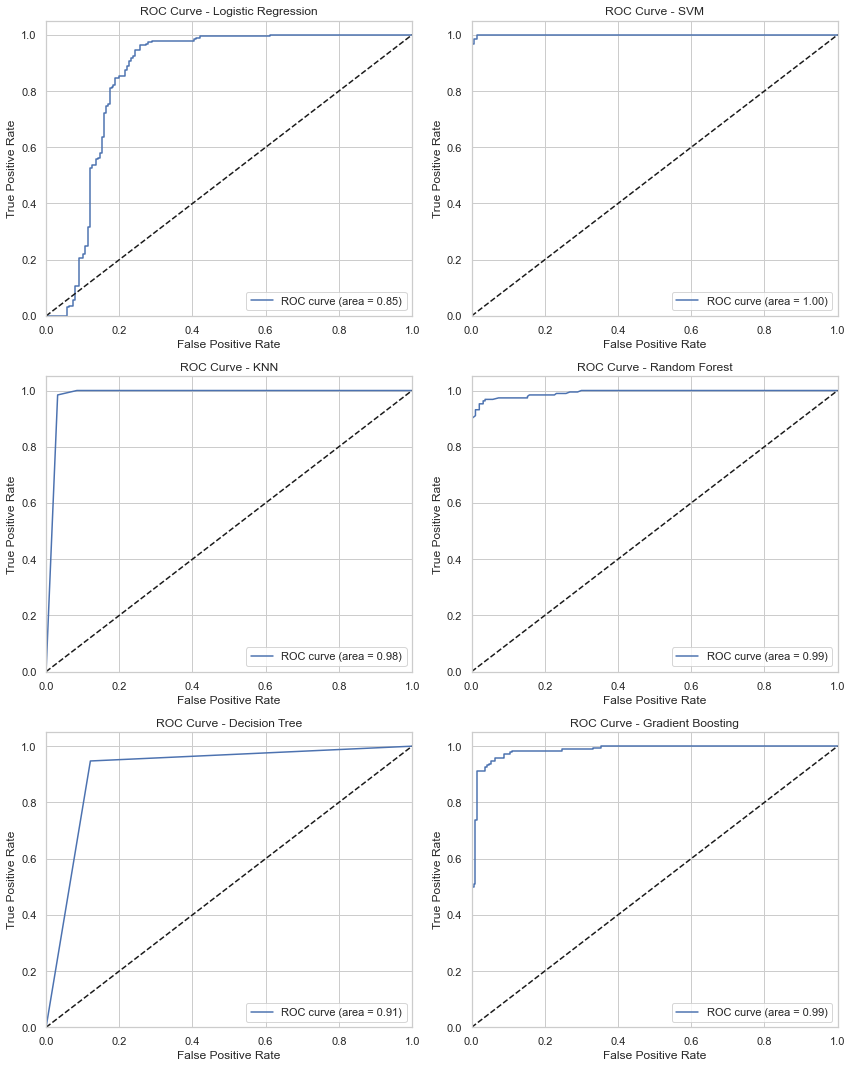

In [44]:
# Use only the selected features
selected_features = ['group', 'sum_qchat', 'Q02', 'Q03', 'Q04', 'Q06', 'Q20', 'Q22', 'Q23', 'Q24']
X = df_balanced[selected_features]
y = df_balanced['asd_risk']  # Target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Prepare for ROC curve grid
fig, axes = plt.subplots(3, 2, figsize=(12, 15))  # 2 rows, 3 columns
axes = axes.flatten()  # Flatten to iterate easily

# Evaluate each model and plot ROC curve
for i, (name, model) in enumerate(models.items()):
    # Train the model
    model.fit(X_train_pca, y_train)
    
    # Predictions
    y_proba = model.predict_proba(X_test_pca)[:, 1]
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # Plot ROC curve in the respective subplot
    axes[i].plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
    axes[i].plot([0, 1], [0, 1], 'k--')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'ROC Curve - {name}')
    axes[i].legend(loc="lower right")

# Remove any empty subplots (if models < rows*cols)
for j in range(i + 1, 6):
    fig.delaxes(axes[j])

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the grid of ROC curves
plt.show()

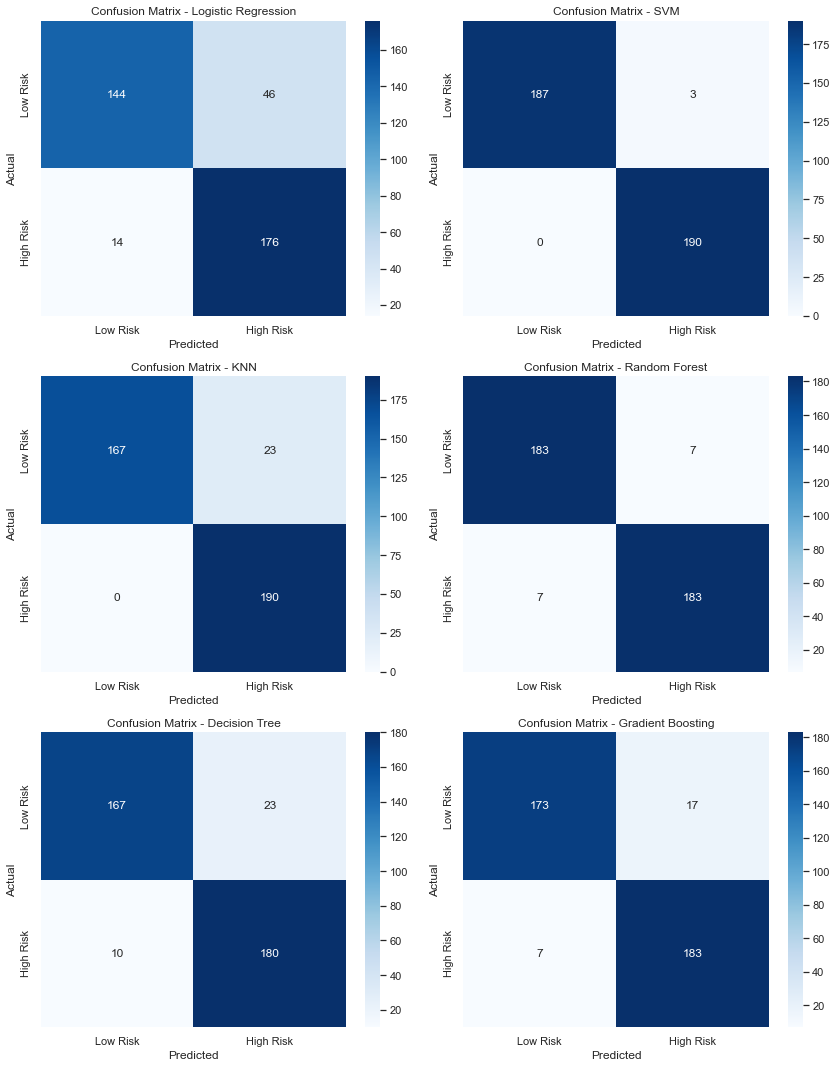

In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Assume df_balanced is your DataFrame
# Use only the selected features
selected_features = ['group', 'sum_qchat', 'Q02', 'Q03', 'Q04', 'Q06', 'Q20', 'Q22', 'Q23', 'Q24']
X = df_balanced[selected_features]
y = df_balanced['asd_risk']  # Target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Prepare for confusion matrix grid
fig, axes = plt.subplots(3, 2, figsize=(12, 15))  # 3 rows, 2 columns
axes = axes.flatten()  # Flatten to iterate easily

# Evaluate each model and plot confusion matrix
for i, (name, model) in enumerate(models.items()):
    # Train the model
    model.fit(X_train_pca, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_pca)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot confusion matrix in the respective subplot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_title(f'Confusion Matrix - {name}')

# Remove any empty subplots (if models < rows*cols)
for j in range(i + 1, 6):
    fig.delaxes(axes[j])

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the grid of confusion matrices
plt.show()

In [46]:
# Use only the selected features
selected_features = ['group', 'sum_qchat', 'Q02', 'Q03', 'Q04', 'Q06', 'Q20', 'Q22', 'Q23', 'Q24']
X = df_balanced[selected_features]
y = df_balanced['asd_risk']  # Target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Evaluate each model and print TP, TN, FP, FN
for name, model in models.items():
    # Train the model
    model.fit(X_train_pca, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_pca)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Calculate TP, TN, FP, FN
    TN, FP, FN, TP = cm.ravel()
    
    # Print out the results
    print(f"Model: {name}")
    print(f"True Positives (TP): {TP}")
    print(f"True Negatives (TN): {TN}")
    print(f"False Positives (FP): {FP}")
    print(f"False Negatives (FN): {FN}")
    print("-" * 30)


Model: Logistic Regression
True Positives (TP): 176
True Negatives (TN): 144
False Positives (FP): 46
False Negatives (FN): 14
------------------------------
Model: SVM
True Positives (TP): 190
True Negatives (TN): 187
False Positives (FP): 3
False Negatives (FN): 0
------------------------------
Model: KNN
True Positives (TP): 190
True Negatives (TN): 167
False Positives (FP): 23
False Negatives (FN): 0
------------------------------
Model: Random Forest
True Positives (TP): 183
True Negatives (TN): 183
False Positives (FP): 7
False Negatives (FN): 7
------------------------------
Model: Decision Tree
True Positives (TP): 180
True Negatives (TN): 167
False Positives (FP): 23
False Negatives (FN): 10
------------------------------
Model: Gradient Boosting
True Positives (TP): 183
True Negatives (TN): 173
False Positives (FP): 17
False Negatives (FN): 7
------------------------------


In [47]:
from tabulate import tabulate

# Define the models and their corresponding performance metrics
models = ["Logistic Regression", "SVM", "KNN", "Random Forest", "Decision Tree", "Gradient Boosting"]
accuracy = [0.842, 0.992, 0.939, 0.963, 0.913, 0.937]
recall = [0.926, 1.000, 1.000, 0.963, 0.947, 0.963]
precision = [0.793, 0.984, 0.892, 0.963, 0.887, 0.915]
f1_score = [0.854, 0.992, 0.943, 0.963, 0.916, 0.938]
roc_auc = [0.853, 0.999, 0.984, 0.993, 0.913, 0.985]

# Prepare the data for the table
table_data = []
for i, model in enumerate(models):
    table_data.append([
        model,
        f"{accuracy[i]:.6f}",
        f"{precision[i]:.6f}",
        f"{recall[i]:.6f}",
        f"{f1_score[i]:.6f}",
        f"{roc_auc[i]:.6f}"
    ])

# Define the headers
headers = ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]

# Create and print the table
table = tabulate(table_data, headers=headers, tablefmt="grid")
print("Model Performance Comparison (Selected Features)")
print(table)

Model Performance Comparison (Selected Features)
+---------------------+------------+-------------+----------+------------+-----------+
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   ROC AUC |
+=====================+============+=============+==========+============+===========+
| Logistic Regression |      0.842 |       0.793 |    0.926 |      0.854 |     0.853 |
+---------------------+------------+-------------+----------+------------+-----------+
| SVM                 |      0.992 |       0.984 |    1     |      0.992 |     0.999 |
+---------------------+------------+-------------+----------+------------+-----------+
| KNN                 |      0.939 |       0.892 |    1     |      0.943 |     0.984 |
+---------------------+------------+-------------+----------+------------+-----------+
| Random Forest       |      0.963 |       0.963 |    0.963 |      0.963 |     0.993 |
+---------------------+------------+-------------+----------+------------+-------

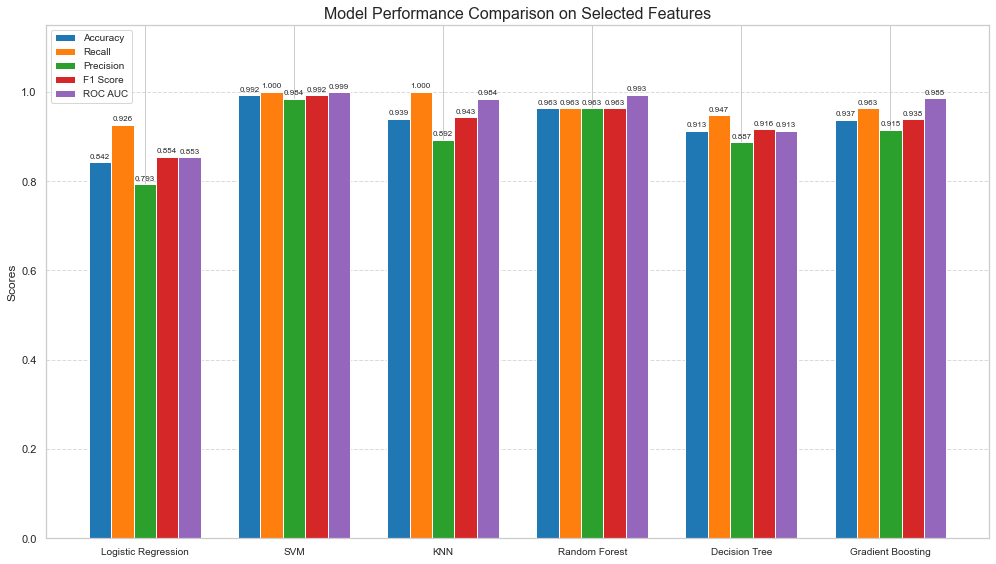

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Define the models and their corresponding performance metrics
models = ["Logistic Regression", "SVM", "KNN", "Random Forest", "Decision Tree", "Gradient Boosting"]
accuracy = [0.842, 0.992, 0.939, 0.963, 0.913, 0.937]
recall = [0.926, 1.000, 1.000, 0.963, 0.947, 0.963]
precision = [0.793, 0.984, 0.892, 0.963, 0.887, 0.915]
f1_score = [0.854, 0.992, 0.943, 0.963, 0.916, 0.938]
roc_auc = [0.853, 0.999, 0.984, 0.993, 0.913, 0.985]


# Set up the bar plot
x = np.arange(len(models))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 8))

# Create bars
rects1 = ax.bar(x - 2*width, accuracy, width, label='Accuracy', color='#1f77b4')
rects2 = ax.bar(x - width, recall, width, label='Recall', color='#ff7f0e')
rects3 = ax.bar(x, precision, width, label='Precision', color='#2ca02c')
rects4 = ax.bar(x + width, f1_score, width, label='F1 Score', color='#d62728')
rects5 = ax.bar(x + 2*width, roc_auc, width, label='ROC AUC', color='#9467bd')

# Customize the plot
ax.set_ylabel('Scores', fontsize=12)
ax.set_title('Model Performance Comparison on Selected Features', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.legend(fontsize=10)

# Add value labels on the bars
def add_value_labels(ax, rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', rotation=0,
                    fontsize=8)

add_value_labels(ax, rects1)
add_value_labels(ax, rects2)
add_value_labels(ax, rects3)
add_value_labels(ax, rects4)
add_value_labels(ax, rects5)

# Adjust layout and display
plt.tight_layout()
plt.ylim(0, 1.15)  # Increased y-axis limit to accommodate labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [49]:
from tabulate import tabulate

# Define the models, their parameters, and corresponding accuracy
models_data = [
    ("LR", "C=1.0, solver='lbfgs'", 0.842),
    ("SVM", "C=1.0, kernel='rbf'", 0.992),
    ("KNN", "n_neighbors=5", 0.939),
    ("RF", "n_estimators=100", 0.963),
    ("DT", "max_depth=None", 0.913),
    ("GB", "n_estimators=100, learning_rate=0.1", 0.937),
    ("LR(Selected features)", "C=1.0, solver='lbfgs'", 0.846),
    ("SVM(Selected features)", "C=1.0, kernel='rbf'", 0.960),
    ("KNN(Selected features)", "n_neighbors=5", 0.907),
    ("RF(Selected features)", "n_estimators=100", 0.933),
    ("DT(Selected features)", "max_depth=None", 0.906),
    ("GB(Selected features)", "n_estimators=100, learning_rate=0.1", 0.906)
]

# Prepare the data for the table
table_data = [
    [model, params, f"{accuracy:.4f}"]
    for model, params, accuracy in models_data
]

# Define the headers
headers = ["Model", "Parameters", "Accuracy"]

# Create and print the table
table = tabulate(table_data, headers=headers, tablefmt="grid")
print("Model Comparison: All Features vs Selected Features")
print(table)

Model Comparison: All Features vs Selected Features
+------------------------+-------------------------------------+------------+
| Model                  | Parameters                          |   Accuracy |
+========================+=====================================+============+
| LR                     | C=1.0, solver='lbfgs'               |      0.842 |
+------------------------+-------------------------------------+------------+
| SVM                    | C=1.0, kernel='rbf'                 |      0.992 |
+------------------------+-------------------------------------+------------+
| KNN                    | n_neighbors=5                       |      0.939 |
+------------------------+-------------------------------------+------------+
| RF                     | n_estimators=100                    |      0.963 |
+------------------------+-------------------------------------+------------+
| DT                     | max_depth=None                      |      0.913 |
+-----------

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       190
           1       0.99      0.98      0.99       190

    accuracy                           0.99       380
   macro avg       0.99      0.99      0.99       380
weighted avg       0.99      0.99      0.99       380



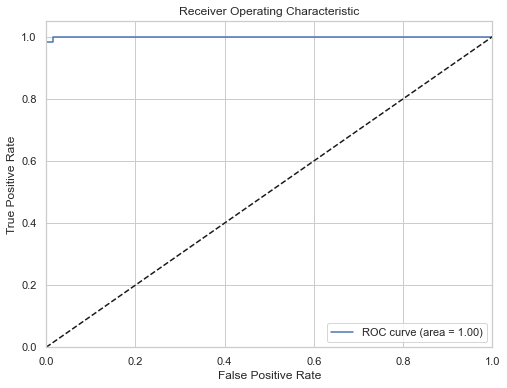

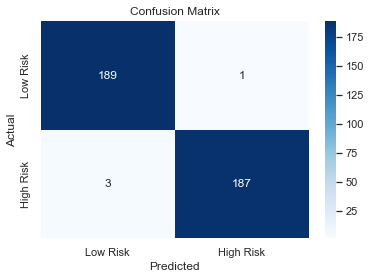

Stacking Model Performance:
Accuracy: 0.989, Precision: 0.995, Recall: 0.984, F1 Score: 0.989, ROC AUC: 1.000
Cross-Validation Performance:
Average Accuracy: 0.970, Average Precision: 0.964, Average Recall: 0.976, Average F1 Score: 0.970, Average ROC AUC: 0.997


In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Assume df_balanced is your DataFrame
# Use only the selected features
selected_features = ['group', 'sum_qchat', 'Q02', 'Q03', 'Q04', 'Q06', 'Q20', 'Q22', 'Q23', 'Q24']
X = df_balanced[selected_features]
y = df_balanced['asd_risk']  # Target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Define base models
base_models = [
    ('lr', LogisticRegression(random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('rf', RandomForestClassifier(random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42))
]

# Define meta-classifier
meta_classifier = LogisticRegression(random_state=42)

# Create stacking classifier
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_classifier, cv=5)

# Train the stacking classifier
stacking_clf.fit(X_train_pca, y_train)

# Evaluate the stacking model
y_pred = stacking_clf.predict(X_test_pca)
y_proba = stacking_clf.predict_proba(X_test_pca)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

# Print classification report
print(classification_report(y_test, y_pred))

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracy = cross_val_score(stacking_clf, X_train_pca, y_train, cv=skf, scoring='accuracy').mean()
cv_precision = cross_val_score(stacking_clf, X_train_pca, y_train, cv=skf, scoring='precision').mean()
cv_recall = cross_val_score(stacking_clf, X_train_pca, y_train, cv=skf, scoring='recall').mean()
cv_f1 = cross_val_score(stacking_clf, X_train_pca, y_train, cv=skf, scoring='f1').mean()
cv_roc_auc = cross_val_score(stacking_clf, X_train_pca, y_train, cv=skf, scoring='roc_auc').mean()

print(f"Stacking Model Performance:\nAccuracy: {accuracy:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, F1 Score: {f1:.3f}, ROC AUC: {roc_auc:.3f}")
print(f"Cross-Validation Performance:\nAverage Accuracy: {cv_accuracy:.3f}, Average Precision: {cv_precision:.3f}, Average Recall: {cv_recall:.3f}, Average F1 Score: {cv_f1:.3f}, Average ROC AUC: {cv_roc_auc:.3f}")

FEATURE IMPORTANCE ANALYSIS

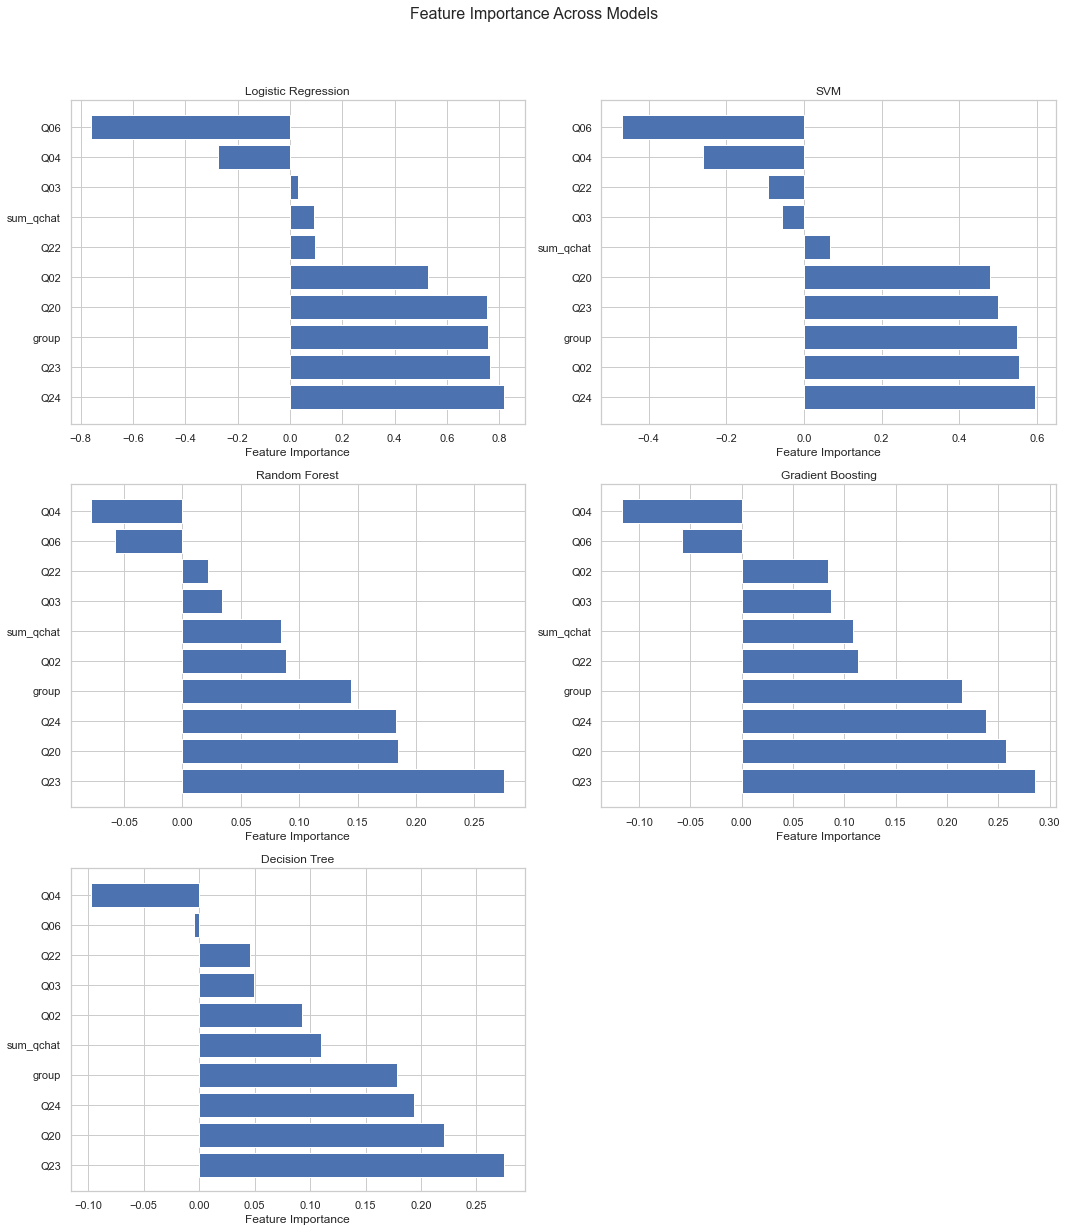

Top 10 Important Features:

Logistic Regression:
Q24: 0.8192
Q23: 0.7659
group: 0.7579
Q20: 0.7537
Q02: 0.5265
Q22: 0.0939
sum_qchat: 0.0907
Q03: 0.0320
Q04: -0.2763
Q06: -0.7593

SVM:
Q24: 0.5954
Q02: 0.5550
group: 0.5483
Q23: 0.5002
Q20: 0.4787
sum_qchat: 0.0672
Q03: -0.0558
Q22: -0.0936
Q04: -0.2591
Q06: -0.4689

Random Forest:
Q23: 0.2757
Q20: 0.1847
Q24: 0.1832
group: 0.1439
Q02: 0.0889
sum_qchat: 0.0847
Q03: 0.0336
Q22: 0.0217
Q06: -0.0581
Q04: -0.0781

Gradient Boosting:
Q23: 0.2860
Q20: 0.2573
Q24: 0.2380
group: 0.2147
Q22: 0.1130
sum_qchat: 0.1089
Q03: 0.0875
Q02: 0.0842
Q06: -0.0585
Q04: -0.1164

Decision Tree:
Q23: 0.2752
Q20: 0.2205
Q24: 0.1940
group: 0.1785
sum_qchat: 0.1096
Q02: 0.0924
Q03: 0.0496
Q22: 0.0456
Q06: -0.0045
Q04: -0.0974


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns

# Define selected features and target
selected_features = ['group', 'sum_qchat', 'Q02', 'Q03', 'Q04', 'Q06', 'Q20', 'Q22', 'Q23', 'Q24']
X = df_balanced[selected_features]
y = df_balanced['asd_risk']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Map PCA components to original features
pca_components = pd.DataFrame(pca.components_, columns=selected_features, index=[f'PCA{i+1}' for i in range(pca.n_components_)])
pca_feature_mapping = {f'PCA{i+1}': feature for i, feature in enumerate(selected_features)}

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(kernel='linear', probability=True, random_state=42),  # Linear kernel for feature importance
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Function to get feature importance
def get_feature_importance(model, X, y):
    if hasattr(model, 'coef_'):
        return np.abs(model.coef_[0])
    elif hasattr(model, 'feature_importances_'):
        return model.feature_importances_
    else:
        return np.zeros(X.shape[1])  # No feature importance available for some models

# Dynamic subplot arrangement
num_models = len(models)
rows = (num_models + 1) // 2  # Calculate rows needed for subplots
fig, axes = plt.subplots(rows, 2, figsize=(15, 6 * rows))
fig.suptitle('Feature Importance Across Models', fontsize=16)

for i, (model_name, model) in enumerate(models.items()):
    model.fit(X_train_pca, y_train)
    importances = get_feature_importance(model, X_test_pca, y_test)
    
    # Map PCA components to original features
    component_importances = np.dot(pca.components_.T, importances)
    
    # Sort features by importance
    indices = np.argsort(component_importances)[::-1]
    feature_names = [pca_feature_mapping[f'PCA{i+1}'] for i in indices]
    
    ax = axes[i // 2, i % 2] if num_models > 1 else axes
    ax.barh(range(len(feature_names)), component_importances[indices])
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels(feature_names)
    ax.set_title(model_name)
    ax.set_xlabel('Feature Importance')

# Remove empty subplots
if num_models % 2 != 0:
    fig.delaxes(axes[-1, -1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Print top 10 important features for each model
print("Top 10 Important Features:")
for model_name, model in models.items():
    model.fit(X_train_pca, y_train)
    importances = get_feature_importance(model, X_test_pca, y_test)
    
    # Map PCA components to original features
    component_importances = np.dot(pca.components_.T, importances)
    
    indices = np.argsort(component_importances)[::-1]
    print(f"\n{model_name}:")
    for i in range(min(10, len(indices))):
        print(f"{pca_feature_mapping[f'PCA{indices[i]+1}']}: {component_importances[indices[i]]:.4f}")

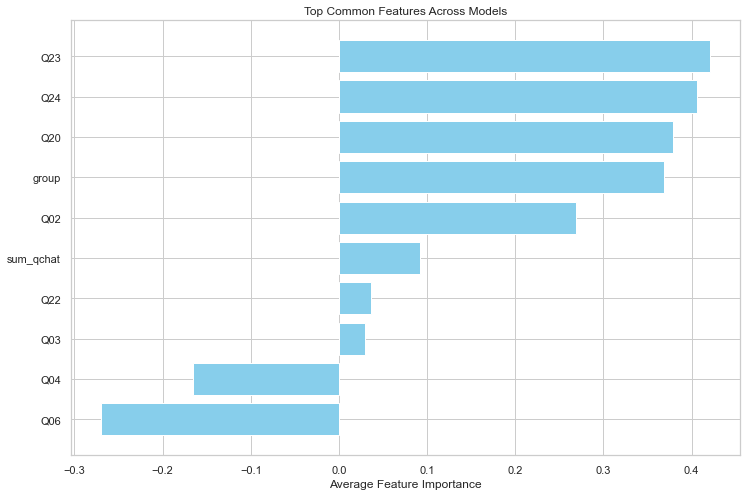

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns


# Define selected features and target
selected_features = ['group', 'sum_qchat', 'Q02', 'Q03', 'Q04', 'Q06', 'Q20', 'Q22', 'Q23', 'Q24']
X = df_balanced[selected_features]
y = df_balanced['asd_risk']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Map PCA components to original features
pca_components = pd.DataFrame(pca.components_, columns=selected_features, index=[f'PCA{i+1}' for i in range(pca.n_components_)])
pca_feature_mapping = {f'PCA{i+1}': feature for i, feature in enumerate(selected_features)}

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(kernel='linear', probability=True, random_state=42),  # Linear kernel for feature importance
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Function to get feature importance
def get_feature_importance(model, X, y):
    if hasattr(model, 'coef_'):
        return np.abs(model.coef_[0])
    elif hasattr(model, 'feature_importances_'):
        return model.feature_importances_
    else:
        return np.zeros(X.shape[1])  # No feature importance available for some models

# Aggregate feature importances across models
feature_importances = {feature: [] for feature in selected_features}

for model_name, model in models.items():
    model.fit(X_train_pca, y_train)
    importances = get_feature_importance(model, X_test_pca, y_test)
    
    # Map PCA components to original features
    component_importances = np.dot(pca.components_.T, importances)
    
    for feature, importance in zip(selected_features, component_importances):
        feature_importances[feature].append(importance)

# Calculate average importance for each feature
avg_feature_importances = {feature: np.mean(importance) for feature, importance in feature_importances.items()}

# Sort features by average importance
sorted_features = sorted(avg_feature_importances.items(), key=lambda x: x[1], reverse=True)

# Plotting
plt.figure(figsize=(12, 8))
features, importances = zip(*sorted_features)
plt.barh(features, importances, color='skyblue')
plt.xlabel('Average Feature Importance')
plt.title('Top Common Features Across Models')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest importance at the top
plt.show()

In [52]:
pip install lime

Note: you may need to restart the kernel to use updated packages.


In [82]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import lime
import lime.lime_tabular

# Define selected features and target
selected_features = ['group', 'sum_qchat', 'Q02', 'Q03', 'Q04', 'Q06', 'Q20', 'Q22', 'Q23', 'Q24']
X = df_balanced[selected_features]
y = df_balanced['asd_risk']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Train all models
for name, model in models.items():
    model.fit(X_train_pca, y_train)

# Initialize LIME explainer with original feature names
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X.columns,
    class_names=['Low Risk', 'High Risk'],
    mode='classification'
)

# Select an instance to explain
i = 0  # Index of the instance in the test set
instance = X_test_scaled[i]

# Generate and print explanations for each model
for name, model in models.items():
    print(f"\nLIME Analysis for {name}:")
    exp = explainer.explain_instance(
        data_row=instance,
        predict_fn=lambda x: model.predict_proba(pca.transform(x)),
        num_features=10  # Number of features to show in the explanation
    )
    exp.show_in_notebook(show_table=True, show_all=False)
    print(exp.as_list())


LIME Analysis for Logistic Regression:


[('group <= -0.51', 0.42537909343679947), ('Q23 <= -0.66', 0.11052300825747693), ('Q20 <= -0.57', 0.07014481663261588), ('Q22 <= -0.91', 0.05930258581741756), ('sum_qchat <= -0.65', 0.04945210760536887), ('-0.88 < Q24 <= 0.18', 0.031662575681144625), ('Q03 <= -1.13', 0.023989091182348266), ('-0.57 < Q04 <= 0.91', -0.022529800103976077), ('-1.06 < Q06 <= -0.29', -0.016702078432437255), ('-1.15 < Q02 <= 0.21', 0.0023766743467657516)]

LIME Analysis for SVM:


[('group <= -0.51', 0.48085195878111603), ('Q20 <= -0.57', 0.12745878504590172), ('Q22 <= -0.91', 0.11526260465818614), ('Q23 <= -0.66', 0.07394132113522604), ('sum_qchat <= -0.65', 0.07179346801568413), ('-0.88 < Q24 <= 0.18', 0.050479048215780496), ('-0.57 < Q04 <= 0.91', 0.031137994406075044), ('-1.06 < Q06 <= -0.29', -0.026401896821526674), ('Q03 <= -1.13', 0.013925469943350489), ('-1.15 < Q02 <= 0.21', -0.010637370717469084)]

LIME Analysis for KNN:


[('group <= -0.51', 0.7041097776794962), ('Q23 <= -0.66', 0.07578321859972102), ('Q20 <= -0.57', 0.06306202274749671), ('Q22 <= -0.91', 0.0560913217036058), ('sum_qchat <= -0.65', 0.05136441883832476), ('-0.88 < Q24 <= 0.18', 0.04454738571385063), ('-0.57 < Q04 <= 0.91', 0.022582510520970663), ('Q03 <= -1.13', 0.00999509547637681), ('-1.06 < Q06 <= -0.29', -0.008045095003610694), ('-1.15 < Q02 <= 0.21', 0.006232160187426963)]

LIME Analysis for Random Forest:


[('group <= -0.51', 0.3527373931333542), ('Q23 <= -0.66', 0.11716276492313239), ('Q20 <= -0.57', 0.09747887535925227), ('Q22 <= -0.91', 0.09170717953061572), ('-0.57 < Q04 <= 0.91', 0.07021736282525948), ('sum_qchat <= -0.65', 0.06055703448812159), ('-0.88 < Q24 <= 0.18', 0.02037213465618357), ('Q03 <= -1.13', 0.013685528450453998), ('-1.15 < Q02 <= 0.21', 0.01048018403510095), ('-1.06 < Q06 <= -0.29', 0.003747689002354819)]

LIME Analysis for Decision Tree:


[('group <= -0.51', 0.41744752132050505), ('Q23 <= -0.66', 0.1688175046488549), ('Q20 <= -0.57', 0.12790539696217662), ('Q22 <= -0.91', 0.10151614411272204), ('Q03 <= -1.13', -0.04200624522001717), ('-0.88 < Q24 <= 0.18', 0.02788289588184275), ('-1.06 < Q06 <= -0.29', -0.02685285241570269), ('-1.15 < Q02 <= 0.21', 0.008748531320667427), ('sum_qchat <= -0.65', -0.005891683980654284), ('-0.57 < Q04 <= 0.91', 0.004903024880931125)]

LIME Analysis for Gradient Boosting:


[('group <= -0.51', 0.37733987946758796), ('Q22 <= -0.91', 0.125174802204708), ('Q20 <= -0.57', 0.12374505710734175), ('Q23 <= -0.66', 0.11521921396378515), ('-0.57 < Q04 <= 0.91', 0.0812916700461013), ('-0.88 < Q24 <= 0.18', 0.04901953724923378), ('sum_qchat <= -0.65', 0.04653036506047633), ('Q03 <= -1.13', 0.02111030130405442), ('-1.15 < Q02 <= 0.21', 0.015082198430431466), ('-1.06 < Q06 <= -0.29', 0.013220338108146696)]


[Interactive LIME HTML output removed to keep this notebook viewable on GitHub. See images/lime_svm_explanation.png and the dissertation PDF for the LIME results.]
